In [1]:
# napari-env environment
from anndata import AnnData, read_h5ad
import scanpy as sc
import pandas as pd
import pydeseq2
import scipy
import openpyxl
import numpy as np
import re
import os
import seaborn as sns

In [2]:
#import sys
#!{sys.executable} -m pip install pydeseq2

In [3]:
#import sys
#!conda install --yes --prefix {sys.prefix} openpyxl

In [4]:
def process_metadata_file(metadata_file):
    print(metadata_file)
    file = pd.ExcelFile(metadata_file)
    sheets = file.sheet_names
    
    seq_metadata = pd.read_excel(metadata_file, sheet_name = "Sequence file", skiprows = [1,2,3,4])
    lib_metadata = pd.read_excel(metadata_file, sheet_name = "Library preparation", skiprows = [1,2,3,4])

    cell_line_sheet = [x for x in sheets if "ell line" in x and "ifferentiated" not in x]
    if len(cell_line_sheet) != 1:
        print('Could not find cell line sheet name in: ' + sheets)
        return None
    cell_line_sheet = cell_line_sheet[0]
    cell_metadata = pd.read_excel(metadata_file, sheet_name = cell_line_sheet, skiprows = [1,2,3,4])

    diff_cell_line_sheet = [x for x in sheets if "Differentiated" in x]
    if len(diff_cell_line_sheet) != 1:
        print('Could not find differentiated cell line sheet name in: ' + sheets)
        return None
    diff_cell_line_sheet = diff_cell_line_sheet[0]
    diff_cell_metadata = pd.read_excel(metadata_file, sheet_name = diff_cell_line_sheet, skiprows = [1,2,3,4])

    # For the revised v7_JAX_RNASeq*_Prod.xlsx metadata files from Fred Hutch:
    #   In the Sequence file tab, the column is called 'INPUT LIBRARY PREPARATION ID (Required)'
    #   In the Library preparation tab, the column is called 'LIBRARY PREPARATION ID (Required)'
    left_on = [s for s in seq_metadata.columns if re.match('.*input library preparation.*', s, re.IGNORECASE) is not None]
    if len(left_on) != 1:
        print('Could not find input library preparation id column in: ' + seq_metadata.columns)
        return None
    metadata = pd.merge(seq_metadata, lib_metadata, 
                        left_on = left_on,
                        right_on = ["LIBRARY PREPARATION ID (Required)"])

    # For the revised v7_JAX_RNASeq*_Prod.xlsx metadata files from Fred Hutch:
    #   In the Library preparation tab (and the merged metadata above), the column is called
    #      'INPUT DIFFERENTIATED PRODUCT ID (Required)'
    #   In the Differentiated product tab, the column is called DIFFERENTIATED PRODUCT ID (Required)'
    left_on = [s for s in metadata.columns if re.match('.*DIFFERENTIATED.*ID.*', s, re.IGNORECASE) is not None]
    if len(left_on) != 1:
        print('Could not find left DIFFERENTIATED CELL LINE ID column in: ' + metadata.columns)
        return None
    #right_on = [s for s in diff_cell_metadata.columns if re.match('.*DIFFERENTIATED.*ID.*', s, re.IGNORECASE) is not None]
    right_on = [s for s in diff_cell_metadata.columns if s in ['DIFFERENTIATED CELL LINE ID (Required)', 'DIFFERENTIATED PRODUCT ID (Required)']]
    if len(right_on) != 1:
        print('Could not find right DIFFERENTIATED CELL LINE ID column in: ' + diff_cell_metadata.columns)
        return None
    metadata = pd.merge(metadata, diff_cell_metadata,
                       left_on = left_on,
                       right_on = right_on)
    metadata = metadata[metadata['READ INDEX (Required)'] == 'read1'].reset_index()
    run_id_col = 'RUN ID'
    if run_id_col not in metadata.columns:
        run_id_col = 'LANE INDEX'
    time_point_val_col = 'TIMEPOINT VALUE'
    if time_point_val_col not in metadata.columns:
        time_point_val_col = 'TIMEPOINT VALUE (Required)'
    model_system_col = 'Model System'
    if model_system_col not in metadata.columns:
        model_system_col = 'MODEL SYSTEM'
    
    cols = ['FILE NAME (Required)', run_id_col, time_point_val_col, model_system_col]
    # print(metadata.columns)
    metadata = metadata[cols]
    metadata.columns = ['FILE NAME (Required)', 'RUN ID', 'TIMEPOINT VALUE', 'Model System']
    
    return metadata

def normalize_bulk_data(bulk_seq):
    bulk_ad = AnnData(bulk_seq.T)
    sc.pp.normalize_total(bulk_ad, target_sum=1e6, layer=None)
    bulk_ad = bulk_ad.to_df().T.reset_index(names = ['GeneSymbol'])
    return bulk_ad

def add_symbols(bulk_seq, gene_names_and_ids):
    bulk_seq = bulk_seq.merge(gene_names_and_ids, left_on = ['Name'], right_on = ["gene_id"])
    cols = bulk_seq.columns
    cols = [x for x in cols if x not in ['Name', 'gene_id', 'gene_name']]
    gene_symbols = bulk_seq.gene_name
    bulk_seq.index = gene_symbols
    bulk_seq = bulk_seq.loc[:,cols]
    return bulk_seq

def split_bulk_into_batches(sample_batches, bulk_ad, bulk_mixture_prefix):
    for batch in np.unique(sample_batches.batch):
        print(batch)
        samples = sample_batches[sample_batches.batch == batch].sample_name.values
        print(samples)
        cols = ['GeneSymbol', *samples]
        found_cols = [x for x in cols if x in bulk_ad.columns] 
        if len(found_cols) != len(cols):
            print('Missing columns:\n')
            print(set(cols).difference(set(found_cols)))
        if len(found_cols) > 2:
            bulk_ad_sub = bulk_ad.loc[:, found_cols]
            bulk_ad_sub.to_csv(bulk_mixture_prefix + '_' + batch + '.tsv', sep="\t", index=False)
            print(bulk_ad_sub.shape)
        print('\n')

In [5]:
# Use new annotations that Anshul, Dylan, and Juliana agreed on in Oct, 2025
use_new_shoe_umap_annotations = True

In [6]:
scrna_seq_file = '/sdata/activities/white-morphic/users/whitebr/JAX/Early_Development_Differentiation_Hypoxia_Normoxia.h5ad'
raw_scrna_seq_file = '/sdata/activities/white-morphic/users/whitebr/JAX/Early_Development_Differentiation_Hypoxia_Normoxia_Raw.h5ad'
# Note, according to metadata file /projects/activities/morphic/dpc/data/chromium/SC2300778_WT-4-5/pipeline-metadata.json
# scRNA-seq was generated using gencode32: "reference_input_gtf_files": "gencode.v32.primary_assembly.annotation.gtf.filtered"
# So, we should use that for bulk data.
# Unfortunately, future DRACC releases used gencode44
if use_new_shoe_umap_annotations:
    shoe_umap_annotation_file = '/sdata/activities/white-morphic/users/whitebr/Hypoxia_normoxia_shoeUmap_new_annotations_dylan_Oct2025.csv'
    shoe_umap_annotations = pd.read_csv(shoe_umap_annotation_file, index_col = 0)
    # shoe_umap_annotations = pd.read_csv(shoe_umap_annotation_file)
    # shoe_umap_annotations.columns.values[0] = 'cell_id'
    cell_ids = [x.split('-')[0] + '-1-' + str(y) for x,y in zip(shoe_umap_annotations.index, shoe_umap_annotations['sample'])]
    shoe_umap_annotations['cell_id'] = cell_ids

In [96]:
sig_matrix_file = '/sdata/activities/white-morphic/users/whitebr/JAX/Early_Development_Differentiation_Hypoxia_Normoxia_Raw_300_ExM_PrSyn_CTB.tsv'
if use_new_shoe_umap_annotations:
    sig_matrix_file = '/sdata/activities/white-morphic/users/whitebr/JAX/ED_new_anno_Hyp_Normo_Raw_300_ExM_PrSyn_CTB.tsv'

In [8]:
base_dir = '/sdata/activities/white-morphic/data/jax2/raw/'

# Fred Hutch repo metadata dir
fhcc_github_metadata_dir = '/sdata/activities/white-morphic/users/whitebr/resources/MorPhiC_bulk_RNAseq/data/metadata_spreadsheets/'

metadata_files = [base_dir + 'Dec2023/metadata/JAX_RNAseq_ExtraEmbryonic_metadata.xlsx',
                  base_dir + 'June-2024/JAX_RNAseq4_ExEm_brain/metadata/JAX_RNAseq4_ExEm_brain_metadata.xlsx',
                  base_dir + 'June-2024/JAX_RNAseq_Neuroectoderm/JAX_RNAseq_Neuroectoderm_metadata_corrected.xlsx',
                  base_dir + 'May2024/metadata/JAX_RNAseq2_ExtraEmbryonic_metadata.xlsx',
                  base_dir + 'September-2024/JAX_RNAseq5_ExE_CBO/metadata/STUDY5_DPC_Metadata_template_v2.xlsx',
                  base_dir + 'September-2024/JAX_RNAseq6_Diverse/metadata/STUDY6_DPC_Metadata_template_v3.xlsx',
                  base_dir + 'September-2024/JAX_RNAseq7_Reversion/metadata/STUDY7_DPC_Metadata_template_v2.xlsx',
                  base_dir + 'MorPhiC_Release_June_2025/JAX_RNAseq08/metadata/JAX_RNAseq08.xlsx',
                  base_dir + 'MorPhiC_Release_June_2025/JAX_RNAseq09/metadata/JAX_RNAseq09.xlsx',
                  base_dir + 'MorPhiC_Release_June_2025/JAX_RNAseq10/metadata/JAX_RNAseq10.xlsx',
                  base_dir + 'MorPhiC_Release_June_2025/JAX_RNAseq11/metadata/JAX_RNAseq11.xlsx']

new_metadata_files = [fhcc_github_metadata_dir + 'v7_JAX_RNAseq1_Prod.xlsx',
                      fhcc_github_metadata_dir + 'v7_JAX_RNAseq2_Prod.xlsx',
                      fhcc_github_metadata_dir + 'v7_JAX_RNAseq3_Prod.xlsx',
                      fhcc_github_metadata_dir + 'v7_JAX_RNAseq4_Prod.xlsx',
                      fhcc_github_metadata_dir + 'v7_JAX_RNAseq5_Prod.xlsx',
                      fhcc_github_metadata_dir + 'v7_JAX_RNAseq6_Prod.xlsx',
                      fhcc_github_metadata_dir + 'v7_JAX_RNAseq7_Prod.xlsx',
                      fhcc_github_metadata_dir + 'JAX_RNAseq08.xlsx',
                      fhcc_github_metadata_dir + 'JAX_RNAseq09.xlsx',
                      fhcc_github_metadata_dir + 'JAX_RNAseq10.xlsx',
                      fhcc_github_metadata_dir + 'JAX_RNAseq11.xlsx']

# As we revise the results with new cell-level annotations, also use updated metadata sheets from Fred Hutch
if use_new_shoe_umap_annotations:
    metadata_files = new_metadata_files

data_files = [base_dir + 'Dec2023/processed/release110-gencode44/Tables/genesCounts.csv',
              base_dir + 'June-2024/JAX_RNAseq4_ExEm_brain/processed/release110-gencode44/Tables/genesCounts.csv',
              base_dir + 'June-2024/JAX_RNAseq_Neuroectoderm/processed/release110-gencode44/Tables/genesCounts.csv',
              base_dir + 'May2024/processed/release110-gencode44/Tables/genesCounts.csv',
              base_dir + 'September-2024/JAX_RNAseq5_ExE_CBO/processed/release110-gencode44/Tables/genesCounts.csv',
              base_dir + 'September-2024/JAX_RNAseq6_Diverse/processed/release110-gencode44/Tables/genesCounts.csv',
              base_dir + 'September-2024/JAX_RNAseq7_Reversion/processed/release110-gencode44/Tables/genesCounts.csv',
              base_dir + 'MorPhiC_Release_June_2025/JAX_RNAseq08/processed/Tables/genesCounts.csv',
              base_dir + 'MorPhiC_Release_June_2025/JAX_RNAseq09/processed/Tables/genesCounts.csv',
              base_dir + 'MorPhiC_Release_June_2025/JAX_RNAseq10/processed/Tables/genesCounts.csv',
              base_dir + 'MorPhiC_Release_June_2025/JAX_RNAseq11/processed/Tables/genesCounts.csv']

In [9]:
bulk_metadatas = [process_metadata_file(metadata_file).assign(metadata_file = metadata_file) for metadata_file in metadata_files]              

/sdata/activities/white-morphic/users/whitebr/resources/MorPhiC_bulk_RNAseq/data/metadata_spreadsheets/v7_JAX_RNAseq1_Prod.xlsx
/sdata/activities/white-morphic/users/whitebr/resources/MorPhiC_bulk_RNAseq/data/metadata_spreadsheets/v7_JAX_RNAseq2_Prod.xlsx
/sdata/activities/white-morphic/users/whitebr/resources/MorPhiC_bulk_RNAseq/data/metadata_spreadsheets/v7_JAX_RNAseq3_Prod.xlsx
/sdata/activities/white-morphic/users/whitebr/resources/MorPhiC_bulk_RNAseq/data/metadata_spreadsheets/v7_JAX_RNAseq4_Prod.xlsx
/sdata/activities/white-morphic/users/whitebr/resources/MorPhiC_bulk_RNAseq/data/metadata_spreadsheets/v7_JAX_RNAseq5_Prod.xlsx
/sdata/activities/white-morphic/users/whitebr/resources/MorPhiC_bulk_RNAseq/data/metadata_spreadsheets/v7_JAX_RNAseq6_Prod.xlsx
/sdata/activities/white-morphic/users/whitebr/resources/MorPhiC_bulk_RNAseq/data/metadata_spreadsheets/v7_JAX_RNAseq7_Prod.xlsx
/sdata/activities/white-morphic/users/whitebr/resources/MorPhiC_bulk_RNAseq/data/metadata_spreadsheets/J

In [10]:
bulk_metadata = pd.concat(bulk_metadatas, ignore_index = True)

In [11]:
np.unique(bulk_metadata['Model System'])

array(['Cortical brain (dorsal forebrain patterning)',
       'Extra-embryonic primitive syncytial cells', 'endoderm',
       'extra-embryonic mesenchymal cells',
       'extra-embryonic primitive syncytial cells',
       'fibroblast of villous mesenchyme (CL:0002558)', 'mesoderm',
       'primitive syncytium'], dtype=object)

In [12]:
np.unique(bulk_metadata['RUN ID'])

array(['20230228_23-scbct-008', '20230424_23-scbct-028-run3',
       '20230508_23-scbct-039-run2', '20230522_23-scbct-052',
       '20230809_23-robson-005-run2', '20230809_23-robson-007-run2',
       '20230824_23-scbct-092', '20230918_23-robson-008',
       '20230918_23-robson-009', '20230918_23-robson-010',
       '20231004_23-robson-011', '20231124_23-robson-013',
       '20231214_23-robson-016', '20231226_23-robson-018',
       '20240131_23-robson-020', '20240307_24-robson-002',
       '20240307_24-robson-003', '20240307_24-robson-004',
       '20240307_24-robson-005', '20240307_24-robson-006',
       '20240418_24-robson-007', '20240418_24-robson-010',
       '20240429_24-robson-007', '20240429_24-robson-014',
       '20240429_24-robson-015', '20240508_24-robson-017',
       '20240617_24-robson-018', '20240627_24-robson-019',
       '20240801_24-robson-023', '20240801_24-robson-024',
       '20240909_GT24-RobsonP-19', '20241202_GT24-RobsonP-94',
       '20250121_GT24-RobsonP-137', '

In [13]:
# Only take the extra-embryonic datasets ...
bulk_metadata = bulk_metadata[["embryonic" in x or "syncytium" in x for x in bulk_metadata['Model System']]].reset_index()
# ... and ensure they are all at day 6 (which are when the scRNA-seq used for deconvolution are taken)
np.unique(bulk_metadata['Model System'])

array(['Extra-embryonic primitive syncytial cells',
       'extra-embryonic mesenchymal cells',
       'extra-embryonic primitive syncytial cells', 'primitive syncytium'],
      dtype=object)

In [14]:
# Note that all of these data are from Day 6

In [15]:
print(bulk_metadata['TIMEPOINT VALUE'].unique())

[6]


In [16]:
sample_batches = bulk_metadata.loc[:,['FILE NAME (Required)', 'RUN ID', 'metadata_file']]
sample_batches.columns = ['sample_name','batch','metadata_file']
sample_batches = sample_batches.loc[["R1" in x for x in sample_batches.sample_name],:].copy()
sample_batches.sample_name = [x.replace("_R1_001.fastq.gz","") for x in sample_batches.sample_name]
sample_batches.index = sample_batches.sample_name
print(np.unique(sample_batches.batch))

['20230809_23-robson-005-run2' '20230809_23-robson-007-run2'
 '20230918_23-robson-008' '20230918_23-robson-009'
 '20230918_23-robson-010' '20231004_23-robson-011'
 '20231124_23-robson-013' '20231214_23-robson-016'
 '20231226_23-robson-018' '20240307_24-robson-002'
 '20240307_24-robson-005' '20240418_24-robson-007'
 '20240418_24-robson-010' '20240429_24-robson-007'
 '20240429_24-robson-014' '20240508_24-robson-017'
 '20240617_24-robson-018' '20240909_GT24-RobsonP-19'
 '20250121_GT24-RobsonP-137' '20250207_GT25-RobsonP-14'
 '20250327_GT25-RobsonP-14-run3']


In [17]:
sample_batches[[x == 'GRHL1_PTC_A10_GT23-10501_CGGCGTGA-ACAGGCGC_S30_L001' for x in sample_batches.sample_name]].metadata_file

Series([], Name: metadata_file, dtype: object)

In [18]:
smpl = 'GCM1_GRHL1_WT_2_GT24-02288_CACGAGCG-TGGCAGAT_S204_L005'
sample_batches[[x == smpl for x in sample_batches.sample_name]].metadata_file

Series([], Name: metadata_file, dtype: object)

In [19]:
sample_batches[[x == '20231004_23-robson-008-run2' for x in sample_batches.batch]].metadata_file

Series([], Name: metadata_file, dtype: object)

In [20]:
sample_batches[[x == '20240429_24-robson-007' for x in sample_batches.batch]].metadata_file[0]

/tmp/ipykernel_1155454/2110404782.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sample_batches[[x == '20240429_24-robson-007' for x in sample_batches.batch]].metadata_file[0]


'/sdata/activities/white-morphic/users/whitebr/resources/MorPhiC_bulk_RNAseq/data/metadata_spreadsheets/v7_JAX_RNAseq6_Prod.xlsx'

In [21]:
bulk_datas = [pd.read_csv(bulk_seq_file, sep="\t").set_index('Name') for bulk_seq_file in data_files]

In [22]:
# Some datasets have different genes!
for bulk_data in bulk_datas:
    print(bulk_data.shape[0])

38592
38592
38592
38592
38592
38592
38592
36601
36601
38592
38592


In [23]:
# Restrict to a common set of genes
common_genes = set(bulk_datas[0].index.values)
for bulk_data in bulk_datas:
    common_genes = common_genes.intersection(bulk_data.index.values)
print(len(common_genes))

36298


In [24]:
for idx in np.arange(len(bulk_datas)):
    print(idx)
    bulk_datas[idx] = bulk_datas[idx].loc[list(common_genes),:]

0
1
2
3
4
5
6
7
8
9
10


In [25]:
bulk_data = pd.concat(bulk_datas, axis = 1, ignore_index = False)
bulk_data = bulk_data.reset_index()

In [26]:
cols = bulk_datas[0].columns
cols = cols[["GHRL1_PTC" in x for x in cols]]
cols

Index(['GHRL1_PTC_A09_GT23-10500_TAATACAG-GTGAATAT_S2_L001',
       'GHRL1_PTC_C09_GT23-10502_ATGTAAGT-CATAGAGT_S19_L001',
       'GHRL1_PTC_A10_GT23-10501_CGGCGTGA-ACAGGCGC_S30_L001'],
      dtype='object')

In [27]:
bulk_data

,Name,POU2F3_KO_F04_GT23-10504_GGTACCTT-GACGTCTT_S33_L001,PPARG_PTC_A10_GT23-11454_GCAATGCA-AACGTTCC_S54_L002,GCM1_PTC_A11_GT23-11442_CGTTAGAA-GACCTGAA_S52_L002,GCM1_CE_G6_GT23-11440_AATGCCTC-TGGATCGA_S59_L002,FOSB_CE_C05_GT23-10483_TTATAACC-TCGATATC_S27_L001,PPARG_KO_E02_GT23-11448_CGGACAAC-AATCCGGA_S60_L002,PPARG_CE_D08_GT23-11451_AAGATACT-ATGTAAGT_S61_L002,CE_G07__Normoxia_GT23-11295_TGGATCGA-TATCGCAC_S25_L001,PPARG_WT_1_GT23-11445_TCGTAGTG-CCAAGTCT_S43_L002,...,KOLF2_CBO_Day20_R1_GT24-12063_GACCTGAA-CTCACCAA_S37_L007,KOLF2_CBO_Day20_R4_GT24-12065_CTCTCGTC-AGGTTATA_S59_L007,KOLF2_CBO_Day20_R3_GT24-12064_TCTCTACT-GAACCGCG_S42_L007,KOLF2_CBO_Day32_R2_GT24-12070_TAATACAG-GTGAATAT_S44_L007,KOLF2_CBO_Day25_R2_GT24-12067_TTGGACTC-CTGCTTCC_S52_L007,KOLF2_CBO_Day3_R4_GT24-12056_GGACTTGG-CGTCTGCG_S38_L007,KOLF2_CBO_Day32_R3_GT24-12071_CGGCGTGA-ACAGGCGC_S61_L007,KOLF2_CBO_Day3_R1_GT24-12054_CCGCGGTT-CTAGCGCT_S40_L007,KOLF2_CBO_Day5_R2_GT24-12061_TGGATCGA-TATCGCAC_S54_L007,KOLF2_CBO_Day25_R4_GT24-12068_CAGTAGGC-ATTCGTCA_S43_L007
0,ENSG00000130775,38,19,18,9,19,29,22,33,27,...,81,74,112,40,68,348,59,297,252,66
1,ENSG00000144959,537,231,928,321,568,215,245,429,675,...,126,124,149,159,113,207,233,240,167,101
2,ENSG00000175582,4949,3957,4741,3528,3898,4762,3636,5091,5353,...,4927,4663,5329,7444,6505,3480,8920,3990,2820,5725
3,ENSG00000233412,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,ENSG00000262484,4,0,7,3,2,2,1,0,1,...,72,70,95,29,39,6,32,0,7,49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36293,ENSG00000146221,0,0,0,0,4,6,0,5,2,...,26,22,25,30,30,3,32,6,1,10
36294,ENSG00000228478,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
36295,ENSG00000107854,4788,3636,8385,6591,3821,4330,3352,3320,5243,...,3622,3300,3841,4099,3866,5140,5113,6199,5078,3488
36296,ENSG00000241328,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [84]:
raw_ad = read_h5ad(raw_scrna_seq_file)

In [29]:
all_gene_names_and_ids = pd.DataFrame(data = {'gene_name': raw_ad.var.index, 'gene_id': raw_ad.var.gene_ids})
# Exclude any ambiguous gene names/ids
all_gene_names_and_ids = all_gene_names_and_ids[[not x and not y for x, y in zip(all_gene_names_and_ids.gene_name.duplicated(keep=False), all_gene_names_and_ids.gene_id.duplicated(keep=False))]]

In [30]:
odir = '/sdata/activities/white-morphic/users/whitebr/JAX/csx-bulk-batches/'
if use_new_shoe_umap_annotations:
    odir = '/sdata/activities/white-morphic/users/whitebr/JAX/csx-bulk-batches-new-annotations/'

print(odir)

if not os.path.exists(odir):
    os.makedirs(odir, exist_ok = True)

prefix = odir + 'csx-bulk-batch'
if use_new_shoe_umap_annotations:
    prefix = odir + 'csx-bulk-batch-new-annos'

bulk_gene_bulk_seq = add_symbols(bulk_data, all_gene_names_and_ids)

bulk_gene_bulk_ad = normalize_bulk_data(bulk_gene_bulk_seq)

print(prefix)
split_bulk_into_batches(sample_batches, bulk_gene_bulk_ad, prefix)

/sdata/activities/white-morphic/users/whitebr/JAX/csx-bulk-batches-new-annotations/
/sdata/activities/white-morphic/users/whitebr/JAX/csx-bulk-batches-new-annotations/csx-bulk-batch-new-annos
20230809_23-robson-005-run2
['GHRL1_KO_D02_GT23-10494_TCTCTACT-GAACCGCG_S26_L001'
 'GHRL1_KO_G04_GT23-10495_CTCTCGTC-AGGTTATA_S15_L001'
 'GHRL1_KO_H04_GT23-10496_CCAAGTCT-TCATCCTT_S35_L001'
 'GHRL1_CE_A05_GT23-10497_TTGGACTC-CTGCTTCC_S12_L001'
 'GHRL1_CE_A08_GT23-10498_CAGTAGGC-ATTCGTCA_S39_L001'
 'GHRL1_CE_D07_GT23-10499_TGACGAAT-GCCTACTG_S31_L001'
 'GHRL1_PTC_A09_GT23-10500_TAATACAG-GTGAATAT_S2_L001'
 'GHRL1_PTC_A10_GT23-10501_CGGCGTGA-ACAGGCGC_S30_L001'
 'GHRL1_PTC_C09_GT23-10502_ATGTAAGT-CATAGAGT_S19_L001'
 'KOLF2_GHRL1_2_GT23-10492_TTACAGGA-GCTTGTCA_S6_L001'
 'POU2F3_KO_B04_GT23-10503_GCACGGAC-TGCGAGAC_S14_L001'
 'POU2F3_KO_F04_GT23-10504_GGTACCTT-GACGTCTT_S33_L001'
 'POU2F3_KO_G03_GT23-10505_AACGTTCC-AGTACTCC_S37_L001'
 'POU2F3_CE_B05_GT23-10506_GCAGAATT-TGGCCGGT_S17_L001'
 'POU2F3_CE_A06_GT

In [31]:
# metadata_file = '/sdata/activities/white-morphic/data/jax2/raw/Dec2023/metadata/JAX_RNAseq_ExtraEmbryonic_metadata.xlsx'
# bulk_seq_file = '/sdata/activities/white-morphic/data/jax2/raw/Dec2023/processed/release98-gencode32/Tables/genesCounts.tsv'
# bulk_mixture_prefix = '/sdata/activities/white-morphic/users/whitebr/JAX/JAX_Dec2023_cpms_300_ExM_PrSyn_CTB_subset'
# bulk_seq_file = '/sdata/activities/white-morphic/data/jax2/raw/Dec2023/processed/release110-gencode44/Tables/genesCounts.csv'
bulk_mixture_prefix = '/sdata/activities/white-morphic/users/whitebr/JAX/JAX_Dec2023_cpms_v44'
if use_new_shoe_umap_annotations:
    bulk_mixture_prefix = '/sdata/activities/white-morphic/users/whitebr/JAX/JAX_new_annos_Dec2023_cpms_v44'
print(bulk_mixture_prefix)

/sdata/activities/white-morphic/users/whitebr/JAX/JAX_new_annos_Dec2023_cpms_v44


In [23]:
if False:
    bulk_metadata = pd.read_excel(metadata_file, sheet_name = "Sequence file", skiprows = [1,2,3,4])
    sample_batches = bulk_metadata.loc[:,['FILE NAME (Required)', 'RUN ID']]
    sample_batches.columns = ['sample_name','batch']
    sample_batches = sample_batches.loc[["R1" in x for x in sample_batches.sample_name],:].copy()
    sample_batches.sample_name = [x.replace("_R1_001.fastq.gz","") for x in sample_batches.sample_name]
    sample_batches.index = sample_batches.sample_name

In [108]:
if False:
    bulk_seq = pd.read_csv(bulk_seq_file, sep="\t")
    bulk_seq.shape

In [33]:
ad = read_h5ad(scrna_seq_file)

In [34]:
# Ensure all cell ids in the new shoe umap annotations are in the original anndata
ids_present = [[id in ad.obs.index for id in shoe_umap_annotations.cell_id]]
np.unique(ids_present)

array([ True])

In [35]:
ad6 = ad[ad.obs.Day == '6',:].copy()
ad6.obs.groupby('Annotated Cell Types').size()

/tmp/ipykernel_1155454/2762994020.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ad6.obs.groupby('Annotated Cell Types').size()


Annotated Cell Types
CTB                               2008
EXM                               1111
EXM Progenitor                     322
Early CTB/Prim.Syn. Progenitor     974
Early Prim.Syn. Progenitor        1393
Prim.Syn.                         1075
Prim.Syn. Progenitor               981
TE                                  32
dtype: int64

In [36]:
np.unique(ad6.obs.Samples)

array(['WT-H-6', 'WT-N-6'], dtype=object)

In [37]:
obs = ad6.obs
obs.index
obs['sample']

AAACAAGCAGTTGCCCATTCGGTT-1-8    8
AAACAAGCATCAAGTGATTCGGTT-1-8    8
AAACCAATCACTTCGAATTCGGTT-1-8    8
AAACCAATCGAGGTTGATTCGGTT-1-8    8
AAACCAGGTAAAGCGCATTCGGTT-1-8    8
                               ..
TTTGGCGGTGGAAGCTAACGCCGA-1-9    9
TTTGGCGGTTAATTCGAACGCCGA-1-9    9
TTTGTGAGTAACCCATAACGCCGA-1-9    9
TTTGTGAGTGGCGTAGAACGCCGA-1-9    9
TTTGTGAGTTAGCGCCAACGCCGA-1-9    9
Name: sample, Length: 7896, dtype: category
Categories (2, object): ['8', '9']

In [86]:
if use_new_shoe_umap_annotations:
    ids_present = [[id in raw_ad.obs.index for id in shoe6.index]]
    print(np.unique(ids_present))

[ True]


In [38]:
if use_new_shoe_umap_annotations:
    shoe6 = shoe_umap_annotations[[x == 6 for x in shoe_umap_annotations.Day]].copy()

In [39]:
# Ensure all shoe umap annotation cell ids are in the original anndata

In [40]:
if use_new_shoe_umap_annotations:
    shoe6.index = shoe6.cell_id

In [42]:
# Ensure all cell ids in the new shoe umap annotations are in the original anndata
if use_new_shoe_umap_annotations:
    ids_present = [[id in ad.obs.index for id in shoe6.index]]
    print(np.unique(ids_present))

[ True]


In [43]:
# Note that some cells were dropped from the shoe umap annotations
if use_new_shoe_umap_annotations:
    print(ad6.shape)
    print(shoe6.shape)

(7896, 2236)
(7506, 20)


In [44]:
if use_new_shoe_umap_annotations:
    foo = pd.merge(obs, shoe6, left_index = True, right_index = True)
    foo

In [45]:
# Sanity check: the original annotations are in 'Annotated Cell Types' of the show umap annotations file
# and these are unchanged from those in the anndata
if use_new_shoe_umap_annotations:
    cmp = [[x == y for x, y in zip(foo['Annotated Cell Types_x'], foo['Annotated Cell Types_y'])]]
    print(np.unique(cmp))

[ True]


In [46]:
# The new shoe umap annotations are in new_cell_types ... and those _do_ differ from the original annotations
if use_new_shoe_umap_annotations:
    cmp = [[x == y for x, y in zip(foo['Annotated Cell Types_x'], foo['new_cell_types'])]]
    print(np.unique(cmp))

[False  True]


In [48]:
# Note that the differences between the old and new annotations are _mostly_ pretty minor, with the
# exception that many of the old progenitors have been reassigned into more mature cell types
if use_new_shoe_umap_annotations:
    print(foo[['Annotated Cell Types_x', 'new_cell_types']].groupby(['Annotated Cell Types_x', 'new_cell_types']).size())

Annotated Cell Types_x          new_cell_types                
CTB                             CTB                               1978
                                EXM                                  0
                                EXM Progenitor                       2
                                Early CTB/Prim.Syn. Progenitor       0
                                Prim.Syn.                            3
                                Prim.Syn. Progenitor                 0
                                TE                                   0
EXM                             CTB                                  0
                                EXM                               1080
                                EXM Progenitor                      10
                                Early CTB/Prim.Syn. Progenitor       0
                                Prim.Syn.                            0
                                Prim.Syn. Progenitor                 0
              

/tmp/ipykernel_1155454/1712907791.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(foo[['Annotated Cell Types_x', 'new_cell_types']].groupby(['Annotated Cell Types_x', 'new_cell_types']).size())


In [49]:
if use_new_shoe_umap_annotations:
    # Restrict the day 6 anndata to those cells with annotations (some may have been filtered)
    ad6 = ad6[[x in shoe6.index for x in ad6.obs.index]]
    # Also, make sure the indices are aligned
    ad6 = ad6[shoe6.index]
    same_order = [[x == y for x, y in zip(ad6.obs.index, shoe6.index)]]
    print(np.unique(same_order))
    print(ad6.shape)
    print(shoe6.shape)

[ True]
(7506, 2236)
(7506, 20)


In [50]:
if use_new_shoe_umap_annotations:
    # Merge in the new annotations
    ad6.obs = ad6.obs.merge(how='left',right=shoe6['new_cell_types'], left_index=True, right_index=True)
    print(ad6.obs)

                             sample  n_genes  n_counts  n_genes_by_counts  \
AAACAAGCAGTTGCCCATTCGGTT-1-8      8     6470   24939.0               6470   
AAACAAGCATCAAGTGATTCGGTT-1-8      8     4328   44540.0               4328   
AAACCAATCACTTCGAATTCGGTT-1-8      8     4475    9853.0               4475   
AAACCAATCGAGGTTGATTCGGTT-1-8      8     3740    6919.0               3740   
AAACCAGGTAAAGCGCATTCGGTT-1-8      8     6889   74889.0               6889   
...                             ...      ...       ...                ...   
TTTGGCGGTGGAAGCTAACGCCGA-1-9      9     8645   66602.0               8645   
TTTGGCGGTTAATTCGAACGCCGA-1-9      9     8700   48134.0               8700   
TTTGTGAGTAACCCATAACGCCGA-1-9      9     5629   38115.0               5629   
TTTGTGAGTGGCGTAGAACGCCGA-1-9      9     5239   12431.0               5239   
TTTGTGAGTTAGCGCCAACGCCGA-1-9      9     6062   19745.0               6062   

                              log1p_n_genes_by_counts  total_counts  \
AAAC

In [52]:
cell_type_anno_col = 'Annotated Cell Types'
if use_new_shoe_umap_annotations:
    cell_type_anno_col = 'new_cell_types'
print(cell_type_anno_col)
cell_types = ['Early Prim.Syn. Progenitor', 'Prim.Syn. Progenitor', 'CTB', 'EXM', 'Prim.Syn.']
coarse_cell_types = ['CTB', 'EXM', 'Prim.Syn.']
prsyn_and_exm_cell_types = ['EXM', 'Prim.Syn.']
ad6_sub = ad6[[x in cell_types for x in ad6.obs[cell_type_anno_col]]].copy()
print(ad6_sub.obs.groupby(cell_type_anno_col).size())
ad6_coarse = ad6_sub[[x in coarse_cell_types for x in ad6_sub.obs[cell_type_anno_col]]].copy()
ad6_prsyn_and_exm = ad6_sub[[x in prsyn_and_exm_cell_types for x in ad6_sub.obs[cell_type_anno_col]]].copy()


new_cell_types
new_cell_types
CTB                     2676
EXM                     1080
Prim.Syn.                992
Prim.Syn. Progenitor     920
dtype: int64


In [53]:
ad6_coarse.obs.groupby(['Hyp/Norm', cell_type_anno_col]).size()

/tmp/ipykernel_1155454/1960473324.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ad6_coarse.obs.groupby(['Hyp/Norm', cell_type_anno_col]).size()


Hyp/Norm  new_cell_types
Hypoxia   CTB               2208
          EXM                942
          Prim.Syn.          245
Normoxia  CTB                468
          EXM                138
          Prim.Syn.          747
dtype: int64

In [54]:
# Intentionally showing old/original annotations here
ad6_coarse.obs.groupby(['Hyp/Norm', 'Annotated Cell Types']).size()

/tmp/ipykernel_1155454/3233677680.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ad6_coarse.obs.groupby(['Hyp/Norm', 'Annotated Cell Types']).size()


Hyp/Norm  Annotated Cell Types          
Hypoxia   CTB                               1846
          EXM                                942
          Early CTB/Prim.Syn. Progenitor     355
          Early Prim.Syn. Progenitor           9
          Prim.Syn.                          243
Normoxia  CTB                                135
          EXM                                138
          Early CTB/Prim.Syn. Progenitor      95
          Early Prim.Syn. Progenitor         239
          Prim.Syn.                          746
dtype: int64

In [55]:
# Keep genes in bulk
bulk_gene_names_and_ids = all_gene_names_and_ids[[x in common_genes for x in all_gene_names_and_ids.gene_id.values]]
gene_names_and_ids = bulk_gene_names_and_ids
# Keep genes in filtered scRNA-seq
gene_names_and_ids = gene_names_and_ids[[x in ad.var.gene_ids.values for x in gene_names_and_ids.gene_id.values]]
gene_names_and_ids 

,gene_name,gene_id
SAMD11,SAMD11,ENSG00000187634
HES4,HES4,ENSG00000188290
ISG15,ISG15,ENSG00000187608
RNF223,RNF223,ENSG00000237330
TAS1R3,TAS1R3,ENSG00000169962
...,...,...
MT-ND4L,MT-ND4L,ENSG00000212907
MT-ND4,MT-ND4,ENSG00000198886
MT-ND5,MT-ND5,ENSG00000198786
MT-ND6,MT-ND6,ENSG00000198695


In [56]:
# Note that the data are already log normalized (or, at least, they are negative)
ad6_sub.X

array([[-0.33190379, -0.56607374, -0.358509  , ..., -0.32080366,
         0.79293256, -0.99901077],
       [-0.28858061, -0.52879894, -1.19589906, ...,  0.65749629,
        -0.5335314 ,  0.30871299],
       [-0.38640094, -0.89299665, -1.13858652, ..., -0.52000017,
         1.44654507, -0.06066664],
       ...,
       [-0.18957073, -0.46666891, -0.53181033, ..., -0.05242167,
        -0.48507987, -0.43689604],
       [-0.23542806, -0.36072015, -0.01344936, ...,  0.12827704,
        -0.96380028, -0.06912858],
       [-0.31391298, -0.55808329, -1.11724069, ...,  0.52615215,
        -0.85607663,  0.71668228]])

In [57]:
ad6.X.shape

(7506, 2236)

In [88]:
# raw_ad = raw_ad[[x in ad6_sub.obs.index for x in raw_ad.obs.index],[x in ad6_sub.var_names for x in raw_ad.var_names]]
raw_ad = raw_ad[:,[x in ad6_sub.var_names for x in raw_ad.var_names]]

In [59]:
for ct in ad6_sub.obs[cell_type_anno_col].unique():
    print(ct)
    # pts = True would give us the percent non-zero for each gene in each cluster. We will calculate this explicitly below and add.
    sc.tl.rank_genes_groups(ad6_sub, groupby=cell_type_anno_col, method="wilcoxon", rankby_abs = False, reference = ct, key_added = 'rank_' + ct, pts = False)

EXM
Prim.Syn.
CTB
Prim.Syn. Progenitor


In [60]:
for ct in ad6_coarse.obs[cell_type_anno_col].unique():
    print(ct)
    # pts = True would give us the percent non-zero for each gene in each cluster. We will calculate this explicitly below and add.
    sc.tl.rank_genes_groups(ad6_coarse, groupby=cell_type_anno_col, method="wilcoxon", rankby_abs = False, reference = ct, key_added = 'rank_' + ct, pts = False)

EXM
Prim.Syn.
CTB


In [61]:
for ct in ad6_prsyn_and_exm.obs[cell_type_anno_col].unique():
    print(ct)
    # pts = True would give us the percent non-zero for each gene in each cluster. We will calculate this explicitly below and add.
    sc.tl.rank_genes_groups(ad6_prsyn_and_exm, groupby=cell_type_anno_col, method="wilcoxon", rankby_abs = False, reference = ct, key_added = 'rank_' + ct, pts = False)

EXM
Prim.Syn.


## Define markers for three populations -- EXM, Prim Syn, CTB

In [62]:
dfs = [sc.get.rank_genes_groups_df(ad6_coarse, group=None, key = 'rank_' + ct).assign(ref = ct) for ct in ad6_coarse.obs[cell_type_anno_col].unique()]
coarse_deg_df = pd.concat(dfs, ignore_index=True)
# Only keep genes in common set of genes
coarse_deg_df = coarse_deg_df[[x in gene_names_and_ids.gene_name.values for x in coarse_deg_df.names]].reset_index(drop = True)
coarse_deg_df

,group,names,scores,logfoldchanges,pvals,pvals_adj,ref
0,CTB,MBNL3,45.940807,3.695199,0.0,0.0,EXM
1,CTB,ATP6V1C2,44.992950,4.369170,0.0,0.0,EXM
2,CTB,SYNE2,43.883942,2.426221,0.0,0.0,EXM
3,CTB,CSF3R,42.651665,3.180622,0.0,0.0,EXM
4,CTB,MED12L,42.081264,2.833780,0.0,0.0,EXM
...,...,...,...,...,...,...,...
13411,Prim.Syn.,CCNG2,-40.060974,-3.841056,0.0,0.0,CTB
13412,Prim.Syn.,BCAM,-41.183289,-2.538911,0.0,0.0,CTB
13413,Prim.Syn.,LAMA1,-42.406834,-2.159835,0.0,0.0,CTB
13414,Prim.Syn.,HIST1H1C,-42.565544,-3.655312,0.0,0.0,CTB


In [63]:
# scipy.stats.rankdata
# Assign a rank based on pvalues
coarse_deg_df = coarse_deg_df.groupby(["group", "ref"]).apply(
    lambda x: x.assign(pvals_rank = scipy.stats.rankdata(-1*x['scores']))).reset_index(drop=True)

/tmp/ipykernel_1155454/4084178644.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coarse_deg_df = coarse_deg_df.groupby(["group", "ref"]).apply(


     group     names  logfoldchanges_min  pvals_rank_max
0      EXM     GABRP            4.982519             2.0
1      EXM     TGFBI            6.714618             2.0
5      EXM      TLN2            5.055104             6.0
8      EXM     PRR15            4.841803             9.0
9      EXM     ACTC1            5.275849            10.0
...    ...       ...                 ...             ...
6694   EXM     SYNE2           -2.426221          2234.0
6697   EXM  ATP6V1C2           -4.369170          2235.0
6700   EXM       PGF           -6.241086          2235.0
6702   EXM   SLC43A2           -5.733055          2236.0
6706   EXM     MBNL3           -3.695199          2236.0

[2236 rows x 4 columns]
          group     names  logfoldchanges_min  pvals_rank_max
2     Prim.Syn.    ERVV-2            4.989623             3.0
3     Prim.Syn.    ERVV-1            5.392487             5.0
4     Prim.Syn.   SLC43A2            3.545784             5.0
6     Prim.Syn.      SDC1            5.5634

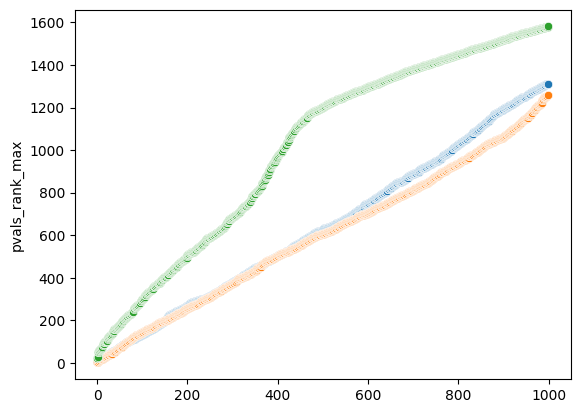

In [64]:
# Take the max pvalue rank -- i.e., worst rank -- across groups (i.e., cell types) for the gene
coarse_summary_deg_df = coarse_deg_df.groupby(['group', 'names']).agg(
    logfoldchanges_min=pd.NamedAgg(column="logfoldchanges", aggfunc="min"),
    pvals_rank_max=pd.NamedAgg(column="pvals_rank", aggfunc="max"),
    #logfoldchanges_max=pd.NamedAgg(column="logfoldchanges", aggfunc="max")
    #pct_nz_group_min=pd.NamedAgg(column="pct_nz_group", aggfunc="min")
).reset_index()
coarse_summary_deg_df = coarse_summary_deg_df.sort_values(by='pvals_rank_max', ascending=True).reset_index(drop=True)
for ct in coarse_summary_deg_df.group.unique():
    tmp = coarse_summary_deg_df[coarse_summary_deg_df.group == ct]
    sns.scatterplot(x=np.arange(1000), y=tmp.pvals_rank_max[:1000])
    #sns.scatterplot(x=np.arange(100), y=tmp.logfoldchanges_min[:100])
    print(tmp)

In [65]:
marker_tbl = coarse_summary_deg_df.groupby('group').apply(lambda x: x[0:300]).reset_index(drop=True)
marker_tbl = marker_tbl[marker_tbl.logfoldchanges_min>1]
marker_tbl

/tmp/ipykernel_1155454/2306359388.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  marker_tbl = coarse_summary_deg_df.groupby('group').apply(lambda x: x[0:300]).reset_index(drop=True)


,group,names,logfoldchanges_min,pvals_rank_max
0,CTB,PTPRU,2.363952,22.0
1,CTB,DOCK5,3.544854,26.0
2,CTB,BCAM,1.354305,52.0
3,CTB,SAT1,2.122768,53.0
4,CTB,CEBPD,1.988236,54.0
...,...,...,...,...
895,Prim.Syn.,OVOL1,1.851061,367.0
896,Prim.Syn.,CSNK2A2,1.562819,370.0
897,Prim.Syn.,CLEC1A,1.988048,372.0
898,Prim.Syn.,ATP6V0A1,1.565628,373.0


## Define markers for two populations -- EXM and Prim Syn

In [68]:
def calculate_deg_summary(ad, gene_names_and_ids):
    cell_types = ad.obs[cell_type_anno_col].unique()
    if(len(cell_types) > 2):
        dfs = [sc.get.rank_genes_groups_df(ad, group=None, key = 'rank_' + ct).assign(ref = ct) for ct in cell_types]
    else:
        dfs = [sc.get.rank_genes_groups_df(ad, group=None, key = 'rank_' + ct).assign(ref = ct).assign(group = [x for x in cell_types if x != ct][0]) for ct in cell_types]    
    coarse_deg_df = pd.concat(dfs, ignore_index=True)
    # Only keep genes in common set of genes
    coarse_deg_df = coarse_deg_df[[x in gene_names_and_ids.gene_name.values for x in coarse_deg_df.names]].reset_index(drop = True)
    coarse_deg_df = coarse_deg_df.groupby(["group", "ref"]).apply(
        lambda x: x.assign(pvals_rank = scipy.stats.rankdata(-1*x['scores']))).reset_index(drop=True)
    coarse_summary_deg_df = coarse_deg_df.groupby(['group', 'names']).agg(
        logfoldchanges_min=pd.NamedAgg(column="logfoldchanges", aggfunc="min"),
        pvals_rank_max=pd.NamedAgg(column="pvals_rank", aggfunc="max"),
        #logfoldchanges_max=pd.NamedAgg(column="logfoldchanges", aggfunc="max")
        #pct_nz_group_min=pd.NamedAgg(column="pct_nz_group", aggfunc="min")
    ).reset_index()
    coarse_summary_deg_df = coarse_summary_deg_df.sort_values(by='pvals_rank_max', ascending=True).reset_index(drop=True)
    if(len(cell_types) > 2):
        for ct in coarse_summary_deg_df.group.unique():
            tmp = coarse_summary_deg_df[coarse_summary_deg_df.group == ct]
            sns.scatterplot(x=np.arange(1000), y=tmp.pvals_rank_max[:1000])
            #sns.scatterplot(x=np.arange(100), y=tmp.logfoldchanges_min[:100])
            print(tmp)
    return coarse_summary_deg_df


In [69]:
coarse_summary_deg_df_prsyn_and_exm = calculate_deg_summary(ad6_prsyn_and_exm, gene_names_and_ids)

/tmp/ipykernel_1155454/927895655.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coarse_deg_df = coarse_deg_df.groupby(["group", "ref"]).apply(


In [70]:
marker_tbl_prsyn_and_exm = coarse_summary_deg_df_prsyn_and_exm.groupby('group').apply(lambda x: x[0:300]).reset_index(drop=True)
marker_tbl_prsyn_and_exm = marker_tbl_prsyn_and_exm[marker_tbl_prsyn_and_exm.logfoldchanges_min>1]
for ct in marker_tbl_prsyn_and_exm.group.unique():
    print(marker_tbl_prsyn_and_exm[marker_tbl_prsyn_and_exm.group == ct])

    group   names  logfoldchanges_min  pvals_rank_max
0     EXM   TGFBI            7.781857             1.0
1     EXM   GABRP            5.859624             2.0
2     EXM   VTCN1            5.334934             3.0
3     EXM    PRTG            5.200418             4.0
4     EXM   CAPN2            5.078759             5.0
..    ...     ...                 ...             ...
295   EXM    DLK2            6.260036           296.0
296   EXM  CRABP2            4.190742           297.0
297   EXM    TCF4            5.758400           298.0
298   EXM  LYPD6B            2.504421           299.0
299   EXM    HCN4            5.267900           300.0

[300 rows x 4 columns]
         group     names  logfoldchanges_min  pvals_rank_max
300  Prim.Syn.   SLC43A2            5.733055             1.0
301  Prim.Syn.       PGF            6.241086             2.0
302  Prim.Syn.    ERVV-2            5.821352             3.0
303  Prim.Syn.     FHDC1            6.540270             4.0
304  Prim.Syn.    ERVV-

/tmp/ipykernel_1155454/3124639802.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  marker_tbl_prsyn_and_exm = coarse_summary_deg_df_prsyn_and_exm.groupby('group').apply(lambda x: x[0:300]).reset_index(drop=True)


In [71]:
marker_tbl_prsyn_and_exm[[x in ['SDC1', 'ERVV-2', 'ERVV-1', 'NECTIN3', 'GCM1'] for x in marker_tbl_prsyn_and_exm.names]]

,group,names,logfoldchanges_min,pvals_rank_max
302,Prim.Syn.,ERVV-2,5.821352,3.0
304,Prim.Syn.,ERVV-1,6.696734,5.0
306,Prim.Syn.,SDC1,6.702898,7.0
315,Prim.Syn.,NECTIN3,4.569546,16.0
360,Prim.Syn.,GCM1,5.298213,61.0


In [72]:
raw_ad.var_names

Index(['SAMD11', 'HES4', 'ISG15', 'RNF223', 'TAS1R3', 'ANKRD65', 'VWA1',
       'ATAD3C', 'PRKCZ', 'HES5',
       ...
       'MT-ND1', 'MT-ND2', 'MT-CO2', 'MT-ATP6', 'MT-ND3', 'MT-ND4L', 'MT-ND4',
       'MT-ND5', 'MT-ND6', 'MT-CYB'],
      dtype='object', length=2236)

In [89]:
if use_new_shoe_umap_annotations:
    # Restrict the day 6 anndata to those cells with annotations (some may have been filtered)
    raw_ad = raw_ad[[x in shoe6.index for x in raw_ad.obs.index]]
    # Also, make sure the indices are aligned
    raw_ad = raw_ad[shoe6.index]
    same_order = [[x == y for x, y in zip(raw_ad.obs.index, shoe6.index)]]
    print(np.unique(same_order))
    print(raw_ad.shape)
    print(shoe6.shape)

if use_new_shoe_umap_annotations:
    # Merge in the new annotations
    raw_ad.obs = raw_ad.obs.merge(how='left',right=shoe6['new_cell_types'], left_index=True, right_index=True)
    print(raw_ad.obs)

[ True]
(7506, 2236)
(7506, 20)
                             sample Samples  Hyp/Norm Day  \
AAACAAGCAGTTGCCCATTCGGTT-1-8      8  WT-H-6   Hypoxia   6   
AAACAAGCATCAAGTGATTCGGTT-1-8      8  WT-H-6   Hypoxia   6   
AAACCAATCACTTCGAATTCGGTT-1-8      8  WT-H-6   Hypoxia   6   
AAACCAATCGAGGTTGATTCGGTT-1-8      8  WT-H-6   Hypoxia   6   
AAACCAGGTAAAGCGCATTCGGTT-1-8      8  WT-H-6   Hypoxia   6   
...                             ...     ...       ...  ..   
TTTGGCGGTGGAAGCTAACGCCGA-1-9      9  WT-N-6  Normoxia   6   
TTTGGCGGTTAATTCGAACGCCGA-1-9      9  WT-N-6  Normoxia   6   
TTTGTGAGTAACCCATAACGCCGA-1-9      9  WT-N-6  Normoxia   6   
TTTGTGAGTGGCGTAGAACGCCGA-1-9      9  WT-N-6  Normoxia   6   
TTTGTGAGTTAGCGCCAACGCCGA-1-9      9  WT-N-6  Normoxia   6   

                                        Annotated Cell Types  \
AAACAAGCAGTTGCCCATTCGGTT-1-8                             EXM   
AAACAAGCATCAAGTGATTCGGTT-1-8                       Prim.Syn.   
AAACCAATCACTTCGAATTCGGTT-1-8               

## Create signature matrix for EXM, Prim Syn, and CTB

In [90]:
# Subset raw scRNA-seq counts to markers of interest
sig_data = raw_ad[[x in ad6_coarse.obs.index for x in raw_ad.obs.index],[x in marker_tbl.names.values for x in raw_ad.var_names.values]].copy()

In [91]:
# CPM normalization
# layer=None -> normalize X in place
sc.pp.normalize_total(sig_data, target_sum=1e6, layer=None)

In [93]:
np.unique(sig_data.obs[cell_type_anno_col])

array(['CTB', 'EXM', 'Prim.Syn.'], dtype=object)

In [94]:
#sig_df = sig_data.to_df().T.astype(int).reset_index(names=['GeneSymbol'])
sig_df = sig_data.to_df().T.reset_index(names=['GeneSymbol'])
sig_df.columns = ['GeneSymbol', *sig_data.obs[cell_type_anno_col].values]
sig_df

,GeneSymbol,EXM,Prim.Syn.,CTB,CTB,Prim.Syn.,Prim.Syn.,CTB,CTB,CTB,...,CTB,EXM,Prim.Syn.,CTB,CTB,CTB,Prim.Syn.,Prim.Syn.,Prim.Syn.,Prim.Syn.
0,HES4,0.000000,0.000000,0.000000,0.000000,52.004784,43.265697,0.000000,0.000000,577.700745,...,0.000000,0.000000,0.000000,0.000000,472.143524,0.000000,47.393368,0.000000,0.000000,0.000000
1,ISG15,760.456299,0.000000,0.000000,1727.115723,2600.239258,346.125580,4065.040771,0.000000,1155.401489,...,442.086639,0.000000,128.644943,683.060120,1888.574097,7452.574707,213.270142,0.000000,212.728241,0.000000
2,PRKCZ,253.485428,3690.822510,7337.526367,6908.462891,3640.334717,5970.666016,2710.027100,2654.867188,1155.401489,...,4244.031738,1244.813354,1715.265869,683.060120,2832.861084,3387.533936,4597.156738,1903.438232,3332.742432,4535.375977
3,HES2,0.000000,354.886780,0.000000,0.000000,1144.105225,259.594177,0.000000,0.000000,0.000000,...,176.834656,0.000000,343.053162,0.000000,0.000000,0.000000,710.900513,5287.328613,1914.554199,1612.578125
4,PLEKHG5,253.485428,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1244.813354,0.000000,0.000000,472.143524,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
784,RAP2C,2281.368896,0.000000,2096.436035,1727.115723,52.004784,216.328476,1355.013550,884.955750,1733.102173,...,1149.425293,3734.439941,42.881645,2732.240479,944.287048,1355.013550,450.236969,30.213305,106.364120,100.786133
785,VGLL1,506.970856,0.000000,3144.654053,3454.231445,208.019135,173.062790,2710.027100,1769.911499,2310.802979,...,5923.960938,414.937775,643.224670,12295.082031,8026.439941,2032.520386,47.393368,0.000000,0.000000,1209.433594
786,GABRE,0.000000,0.000000,4192.872070,3454.231445,156.014343,86.531395,0.000000,0.000000,2310.802979,...,1945.181274,0.000000,0.000000,2049.180420,3777.148193,2032.520386,0.000000,0.000000,0.000000,0.000000
787,BGN,253.485428,6316.984863,0.000000,0.000000,5148.473633,8133.950684,0.000000,0.000000,0.000000,...,442.086639,0.000000,11363.635742,2049.180420,0.000000,677.506775,0.000000,12327.028320,1524.552368,100.786133


In [97]:
print(sig_matrix_file)

/sdata/activities/white-morphic/users/whitebr/JAX/ED_new_anno_Hyp_Normo_Raw_300_ExM_PrSyn_CTB.tsv


In [98]:
# Upload this as a Single Cell Reference Matrix on CIBERSORTx website
sig_df.to_csv(sig_matrix_file, sep="\t", index=False)

In [100]:
sig_df = pd.read_csv(sig_matrix_file, sep="\t")

In [101]:
def rename_dup_string(x):
    if "EXM" in x:
        return "EXM"
    if "Prim.Syn." in x:
        return "Prim.Syn."
    if "CTB" in x:
        return "CTB"
    return x

def rename_prim_syn(x):
    if "Prim.Syn." in x:
        return "Prim"
    return x

In [102]:
sig_df.columns = [rename_dup_string(x) for x in sig_df.columns]

In [103]:
sig_2_cell_types_df = sig_df.loc[:, [x in ['GeneSymbol', 'EXM', 'Prim.Syn.'] for x in sig_df.columns]]

In [104]:
sig_df

,GeneSymbol,EXM,Prim.Syn.,CTB,CTB,Prim.Syn.,Prim.Syn.,CTB,CTB,CTB,...,CTB,EXM,Prim.Syn.,CTB,CTB,CTB,Prim.Syn.,Prim.Syn.,Prim.Syn.,Prim.Syn.
0,HES4,0.00000,0.00000,0.0000,0.0000,52.004784,43.265697,0.0000,0.00000,577.70074,...,0.00000,0.00000,0.000000,0.0000,472.14352,0.0000,47.393368,0.000000,0.00000,0.00000
1,ISG15,760.45630,0.00000,0.0000,1727.1157,2600.239300,346.125580,4065.0408,0.00000,1155.40150,...,442.08664,0.00000,128.644940,683.0601,1888.57410,7452.5747,213.270140,0.000000,212.72824,0.00000
2,PRKCZ,253.48543,3690.82250,7337.5264,6908.4630,3640.334700,5970.666000,2710.0270,2654.86720,1155.40150,...,4244.03170,1244.81340,1715.265900,683.0601,2832.86100,3387.5340,4597.156700,1903.438200,3332.74240,4535.37600
3,HES2,0.00000,354.88678,0.0000,0.0000,1144.105200,259.594180,0.0000,0.00000,0.00000,...,176.83466,0.00000,343.053160,0.0000,0.00000,0.0000,710.900500,5287.328600,1914.55420,1612.57810
4,PLEKHG5,253.48543,0.00000,0.0000,0.0000,0.000000,0.000000,0.0000,0.00000,0.00000,...,0.00000,1244.81340,0.000000,0.0000,472.14352,0.0000,0.000000,0.000000,0.00000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
784,RAP2C,2281.36900,0.00000,2096.4360,1727.1157,52.004784,216.328480,1355.0135,884.95575,1733.10220,...,1149.42530,3734.44000,42.881645,2732.2405,944.28705,1355.0135,450.236970,30.213305,106.36412,100.78613
785,VGLL1,506.97086,0.00000,3144.6540,3454.2314,208.019130,173.062790,2710.0270,1769.91150,2310.80300,...,5923.96100,414.93777,643.224700,12295.0820,8026.44000,2032.5204,47.393368,0.000000,0.00000,1209.43360
786,GABRE,0.00000,0.00000,4192.8720,3454.2314,156.014340,86.531395,0.0000,0.00000,2310.80300,...,1945.18130,0.00000,0.000000,2049.1804,3777.14820,2032.5204,0.000000,0.000000,0.00000,0.00000
787,BGN,253.48543,6316.98500,0.0000,0.0000,5148.473600,8133.950700,0.0000,0.00000,0.00000,...,442.08664,0.00000,11363.636000,2049.1804,0.00000,677.5068,0.000000,12327.028000,1524.55240,100.78613


In [105]:
sig_2_cell_types_df

,GeneSymbol,EXM,Prim.Syn.,Prim.Syn.,Prim.Syn.,EXM,Prim.Syn.,Prim.Syn.,EXM,EXM,...,EXM,Prim.Syn.,Prim.Syn.,Prim.Syn.,EXM,Prim.Syn.,Prim.Syn.,Prim.Syn.,Prim.Syn.,Prim.Syn.
0,HES4,0.00000,0.00000,52.004784,43.265697,0.0000,0.00000,0.000000,0.00000,0.0000,...,0.0000,0.00000,0.00000,0.00000,0.00000,0.000000,47.393368,0.000000,0.00000,0.00000
1,ISG15,760.45630,0.00000,2600.239300,346.125580,0.0000,0.00000,44.915558,4566.21000,0.0000,...,274.1228,152.32292,172.54767,318.96230,0.00000,128.644940,213.270140,0.000000,212.72824,0.00000
2,PRKCZ,253.48543,3690.82250,3640.334700,5970.666000,1661.1295,8077.13670,5839.022500,1522.07000,675.2195,...,0.0000,4645.84900,9921.49100,5953.96300,1244.81340,1715.265900,4597.156700,1903.438200,3332.74240,4535.37600
3,HES2,0.00000,354.88678,1144.105200,259.594180,0.0000,151.44630,179.662230,0.00000,0.0000,...,0.0000,913.93756,517.64300,3668.06640,0.00000,343.053160,710.900500,5287.328600,1914.55420,1612.57810
4,PLEKHG5,253.48543,0.00000,0.000000,0.000000,0.0000,0.00000,0.000000,0.00000,0.0000,...,274.1228,0.00000,0.00000,0.00000,1244.81340,0.000000,0.000000,0.000000,0.00000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
784,RAP2C,2281.36900,0.00000,52.004784,216.328480,2214.8394,0.00000,0.000000,2029.42660,2700.8780,...,2192.9824,76.16146,345.09534,159.48116,3734.44000,42.881645,450.236970,30.213305,106.36412,100.78613
785,VGLL1,506.97086,0.00000,208.019130,173.062790,1107.4197,252.41052,179.662230,507.35666,0.0000,...,0.0000,1294.74490,4054.87040,106.32077,414.93777,643.224700,47.393368,0.000000,0.00000,1209.43360
786,GABRE,0.00000,0.00000,156.014340,86.531395,0.0000,0.00000,0.000000,507.35666,0.0000,...,0.0000,0.00000,0.00000,0.00000,0.00000,0.000000,0.000000,0.000000,0.00000,0.00000
787,BGN,253.48543,6316.98500,5148.473600,8133.950700,0.0000,3533.74730,12396.694000,0.00000,0.0000,...,0.0000,685.45320,2156.84600,0.00000,0.00000,11363.636000,0.000000,12327.028000,1524.55240,100.78613


In [106]:
sig_matrix_file_prsyn_and_exm = '/sdata/activities/white-morphic/users/whitebr/JAX/ED_Hyp_Norm_Raw_300_ExM_PrSyn.tsv'
if use_new_shoe_umap_annotations:
    sig_matrix_file_prsyn_and_exm = '/sdata/activities/white-morphic/users/whitebr/JAX/ED_new_anno_Hyp_Norm_Raw_300_ExM_PrSyn.tsv'
sig_2_cell_types_df.to_csv(sig_matrix_file_prsyn_and_exm, sep="\t", index=False)
print(sig_matrix_file_prsyn_and_exm)
# more CIBERSORTx_Job43_Early_Development_Differentiation_Hypoxia_Normoxia_Raw_300_ExM_PrSyn_CTB_inferred_phenoclasses.CIBERSORTx_Job43_Early_Development_Differentiation_Hypoxia_Normoxia_Raw_300_ExM_PrSyn_CTB_inferred_refsample.bm.K999.txt  | cut -f1-3 > JAX_EXM_Prim_Sig_Matrix.txt

/sdata/activities/white-morphic/users/whitebr/JAX/ED_new_anno_Hyp_Norm_Raw_300_ExM_PrSyn.tsv


## Create signature matrix for EXM and Prim Syn

In [107]:
# Subset raw scRNA-seq counts to markers of interest
sig_data_prsyn_and_exm = raw_ad[[x in ad6_prsyn_and_exm.obs.index for x in raw_ad.obs.index],[x in marker_tbl_prsyn_and_exm.names.values for x in raw_ad.var_names.values]].copy()

# CPM normalization
# layer=None -> normalize X in place
sc.pp.normalize_total(sig_data_prsyn_and_exm, target_sum=1e6, layer=None)

print(sig_data_prsyn_and_exm.obs[cell_type_anno_col])

#sig_df_prsyn_and_exm = sig_data_prsyn_and_exm.to_df().T.astype(int).reset_index(names=['GeneSymbol'])
sig_df_prsyn_and_exm = sig_data_prsyn_and_exm.to_df().T.reset_index(names=['GeneSymbol'])
sig_df_prsyn_and_exm.columns = ['GeneSymbol', *sig_data_prsyn_and_exm.obs[cell_type_anno_col].values]

sig_df_prsyn_and_exm.columns = [rename_prim_syn(x) for x in sig_df_prsyn_and_exm.columns]

print(sig_df_prsyn_and_exm)

sig_df_prsyn_and_exm.to_csv(sig_matrix_file_prsyn_and_exm, sep="\t", index=False)
print(sig_matrix_file_prsyn_and_exm)

AAACAAGCAGTTGCCCATTCGGTT-1-8          EXM
AAACAAGCATCAAGTGATTCGGTT-1-8    Prim.Syn.
AAACCAGGTAAAGCGCATTCGGTT-1-8    Prim.Syn.
AAACCAGGTATGGGACATTCGGTT-1-8    Prim.Syn.
AAACGGGCATTCTGTAATTCGGTT-1-8          EXM
                                  ...    
TTTGCCCGTGCCCGATAACGCCGA-1-9    Prim.Syn.
TTTGCTGAGTCGAAGTAACGCCGA-1-9    Prim.Syn.
TTTGGACGTAATGTCCAACGCCGA-1-9    Prim.Syn.
TTTGGACGTCAAAGATAACGCCGA-1-9    Prim.Syn.
TTTGTGAGTAACCCATAACGCCGA-1-9    Prim.Syn.
Name: new_cell_types, Length: 2072, dtype: object
    GeneSymbol         EXM         Prim          Prim          Prim  \
0        PRKCZ  244.558563  3685.068359   3558.537842   6205.594238   
1         HES2    0.000000   354.333496   1118.397583    269.808441   
2      PLEKHG5  244.558563     0.000000      0.000000      0.000000   
3       GPR157    0.000000  4252.001953    762.543823    584.584961   
4     TNFRSF1B  733.675659  9000.070312  21859.589844  15873.730469   
..         ...         ...          ...           ...         

# Instructions for creating signature matrix file on CIBERSORTx website

In [ ]:
# Upload Single cell reference matrix file (see below)
# as a 
# Single Cell Reference Martrix file

In [ ]:
# 1. Create Signature Matrix
# 2. Select Analysis Mode: Custom
#    Select Input Data Type: scRNA-seq
#    Single cell reference matrix file: 
#       Early_Development_Differentiation_Hypoxia_Normoxia_Raw_300_ExM_PrSyn_CTB.tsv (for 3 populations -- ExM, PrSyn, CTB)
#         -or- 
#       ED_Hyp_Norm_Raw_300_ExM_PrSyn.tsv (for 2 pops -- ExM and PrSyn)
#         -or- 
#       ED_new_anno_Hyp_Norm_Raw_300_ExM_PrSyn_CTB.tsv (for 3 pops -- ExM, PrSyn, CTB using new cell type annotations)
#         -or- 
#       ED_new_anno_Hyp_Norm_Raw_300_ExM_PrSyn.tsv (for 2 pops -- ExM and PrSyn using new cell type annotations)
#    Custom Sig File Name: 
#       Early_Development_Differentiation_Hypoxia_Normoxia_Raw_300_ExM_PrSyn_CTB_Sig_Matrix (for 3 populations -- ExM, PrSyn, CTB)
#         -or- 
#       ED_Hyp_Norm_Raw_300_ExM_PrSyn_Sig_Matrix (for 2 pops -- ExM and PrSyn)
#         -or- 
#       ED_new_anno_Hyp_Norm_Raw_300_ExM_PrSyn_CTB_Sig_Matrix (for 3 pops -- ExM, PrSyn, CTB using new cell type annotations))
#         -or- 
#       ED_new_anno_Hyp_Norm_Raw_300_ExM_PrSyn_Sig_Matrix (for 2 pops -- ExM and PrSyn using new cell type annotations)
#    Disable quantile normalization (default)
#    Single Cell Options: 
#       Sampling 1.0
#       Min Expression (log2 space): 0
#       Replicates: 5 (default)
#    Additional Options:
#       kappa: 999 (default)
#       q-value: 1.0 (effectively keep all genes -- we have already done filtered)
#       No. Barcode Genes: min 200 (changed from 300); max 500 (default)

In [ ]:
# For some reason, we get an svd error when we use the above configuration for the 2 populations (ExM and PrSyn, but not CTB).
# Online, this looks like:
#   Error in svd(BG.opt.xpr) : a dimension is zero
#   Calls: CIBERSORTxFractions -> buildSignatureMatrix -> svd
#   Execution halted
# Using docker, this looks like:
#   Error in svd(z, nu = 0, nv = 0) : a dimension is zero
#   Calls: performOptimization -> kappa -> kappa.default -> svd
#   ...
# I could overcome this error by changing sampling to 0.5 in the instructions above.
# That was done for the signature matrix
#    ED_new_anno_Hyp_Norm_Raw_300_ExM_PrSyn_Sig_Matrix
#    whereas ED_new_anno_Hyp_Norm_Raw_300_ExM_PrSyn_CTB_Sig_Matrix used sampling 1.0
# I could also do it with the command
# docker run -v /Users/whitebr/Downloads/:/src/data -v /Users/whitebr/Downloads/output/:/src/outdir cibersortx/fractions            --username brian.white@jax.org --token 52bb80f372d0837760829bbfa321149f            --refsample ED_new_anno_Hyp_Norm_Raw_300_ExM_PrSyn.tsv  --single_cell TRUE --q.value 1.0 --fraction 0 --sampling 0.5

In [ ]:
# This was not used. Instead, I created the signature matrix online.
# docker run -v /Users/whitebr/Downloads/:/src/data -v /Users/whitebr/Downloads/output/:/src/outdir cibersortx/fractions            --username brian.white@jax.org --token 52bb80f372d0837760829bbfa321149f            --refsample ED_Hyp_Norm_Raw_300_ExM_PrSyn.tsv  --single_cell TRUE --q.value 1.0 --fraction 0
# -> CIBERSORTx_ED_Hyp_Norm_Raw_300_ExM_PrSyn_inferred_phenoclasses.CIBERSORTx_ED_Hyp_Norm_Raw_300_ExM_PrSyn_inferred_refsample.bm.K999.txt

# Instructions for running CIBERSORTx

In [ ]:
# 1. Impute Cell Fractions
#    Custom Analysis Mode
#    Signature Matrix File: ED_new_anno_Hyp_Norm_Raw_300_ExM_PrSyn_CTB_Sig_Matrix
#    Mixture file: *new-annos*
#    Enable batch correction
#    Batch correction mode: S-mode
#    Single cell reference matrix file: ED_new_anno_Hyp_Norm_Raw_300_ExM_PrSyn_CTB
#    Disable quantile normalization: true (default)
#    Run in absolute mode (check/true)
#    Permutations: none

# No code below this piont is used. Not sure what is going on. Perhaps limiting genes in bulk mixtures.

In [692]:
# Subset raw bulk RNA-seq counts to markers of interest

In [694]:
gene_names_and_ids

,gene_name,gene_id
SAMD11,SAMD11,ENSG00000187634
HES4,HES4,ENSG00000188290
ISG15,ISG15,ENSG00000187608
RNF223,RNF223,ENSG00000237330
TAS1R3,TAS1R3,ENSG00000169962
...,...,...
MT-ND4L,MT-ND4L,ENSG00000212907
MT-ND4,MT-ND4,ENSG00000198886
MT-ND5,MT-ND5,ENSG00000198786
MT-ND6,MT-ND6,ENSG00000198695


In [80]:
bulk_seq

,Name,POU2F3_KO_F04_GT23-10504_GGTACCTT-GACGTCTT_S33_L001,PPARG_PTC_A10_GT23-11454_GCAATGCA-AACGTTCC_S54_L002,GCM1_PTC_A11_GT23-11442_CGTTAGAA-GACCTGAA_S52_L002,GCM1_CE_G6_GT23-11440_AATGCCTC-TGGATCGA_S59_L002,FOSB_CE_C05_GT23-10483_TTATAACC-TCGATATC_S27_L001,PPARG_KO_E02_GT23-11448_CGGACAAC-AATCCGGA_S60_L002,PPARG_CE_D08_GT23-11451_AAGATACT-ATGTAAGT_S61_L002,CE_G07__Normoxia_GT23-11295_TGGATCGA-TATCGCAC_S25_L001,PPARG_WT_1_GT23-11445_TCGTAGTG-CCAAGTCT_S43_L002,...,GHRL1_KO_G04_GT23-10495_CTCTCGTC-AGGTTATA_S15_L001,ISL1_CE_D01_GT23-12152_TGCGGCGT-TACCGAGG_S15_L001,CE_H06__Normoxia_GT23-11296_AGTTCAGG-TCTGTTGG_S20_L001,KO_A03__Hypoxia_GT23-11303_TGACGAAT-GCCTACTG_S33_L001,GCM1_CE_D6_GT23-11439_GGCATTCT-CAAGCTAG_S49_L002,PTC_G09__Normoxia_GT23-11299_CTCTCGTC-AGGTTATA_S23_L001,FOSB_CE_D07_GT23-10484_GGACTTGG-CGTCTGCG_S22_L001,FOSB_KO_C02_GT23-10489_TGGATCGA-TATCGCAC_S1_L001,PTC_A09__Hypoxia_GT23-11309_AACGTTCC-AGTACTCC_S30_L001,PTC_D10__Hypoxia_GT23-11310_GCAGAATT-TGGCCGGT_S22_L001
0,ENSG00000268674,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,ENSG00000271254,1131,857,1248,1149,917,927,793,849,892,...,575,951,759,501,1069,793,778,858,517,658
2,ENSG00000275063,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,ENSG00000277856,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,ENSG00000276345,2,0,0,3,0,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36596,ENSG00000236651,0,0,2,2,0,2,0,0,0,...,0,2,0,0,1,0,0,2,1,1
36597,ENSG00000222017,0,0,0,0,1,3,0,0,0,...,0,1,0,0,0,2,0,0,2,2
36598,ENSG00000262777,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
36599,ENSG00000247626,401,275,253,135,241,206,226,111,218,...,231,182,151,148,235,145,191,356,94,136


In [ ]:
# working -- use same genes as in "original" bulk mixture JAX_Dec2023_cpms-X20230918_23.robson.009-symbol.tsv

In [24]:
orig_bulk_mixture_file = '/sdata/activities/white-morphic/users/whitebr/JAX/JAX_Dec2023_cpms-X20230918_23-robson-009.tsv'
orig_bulk_seq = pd.read_csv(orig_bulk_mixture_file, sep="\t")

In [19]:
bulk_seq

,Name,POU2F3_KO_F04_GT23-10504_GGTACCTT-GACGTCTT_S33_L001,PPARG_PTC_A10_GT23-11454_GCAATGCA-AACGTTCC_S54_L002,GCM1_PTC_A11_GT23-11442_CGTTAGAA-GACCTGAA_S52_L002,GCM1_CE_G6_GT23-11440_AATGCCTC-TGGATCGA_S59_L002,FOSB_CE_C05_GT23-10483_TTATAACC-TCGATATC_S27_L001,PPARG_KO_E02_GT23-11448_CGGACAAC-AATCCGGA_S60_L002,PPARG_CE_D08_GT23-11451_AAGATACT-ATGTAAGT_S61_L002,CE_G07__Normoxia_GT23-11295_TGGATCGA-TATCGCAC_S25_L001,PPARG_WT_1_GT23-11445_TCGTAGTG-CCAAGTCT_S43_L002,...,GHRL1_KO_G04_GT23-10495_CTCTCGTC-AGGTTATA_S15_L001,ISL1_CE_D01_GT23-12152_TGCGGCGT-TACCGAGG_S15_L001,CE_H06__Normoxia_GT23-11296_AGTTCAGG-TCTGTTGG_S20_L001,KO_A03__Hypoxia_GT23-11303_TGACGAAT-GCCTACTG_S33_L001,GCM1_CE_D6_GT23-11439_GGCATTCT-CAAGCTAG_S49_L002,PTC_G09__Normoxia_GT23-11299_CTCTCGTC-AGGTTATA_S23_L001,FOSB_CE_D07_GT23-10484_GGACTTGG-CGTCTGCG_S22_L001,FOSB_KO_C02_GT23-10489_TGGATCGA-TATCGCAC_S1_L001,PTC_A09__Hypoxia_GT23-11309_AACGTTCC-AGTACTCC_S30_L001,PTC_D10__Hypoxia_GT23-11310_GCAGAATT-TGGCCGGT_S22_L001
0,ENSG00000268674,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,ENSG00000271254,1030,745,1169,1081,874,867,710,761,841,...,515,833,723,477,995,754,746,806,489,603
2,ENSG00000275063,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,ENSG00000277856,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,ENSG00000276345,2,0,0,3,0,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38587,ENSG00000115593,50,76,57,33,44,153,93,15,55,...,59,0,10,39,4,2,21,87,8,29
38588,ENSG00000225921,1106,744,1068,746,987,872,725,785,1055,...,790,719,733,648,971,755,998,1087,554,557
38589,ENSG00000163586,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
38590,ENSG00000110721,742,511,890,501,674,588,493,432,712,...,453,1048,376,363,731,423,591,672,256,374


In [23]:
print(set(orig_bulk_seq.GeneID).issubset(bulk_seq.Name))   
print(set(orig_bulk_seq.GeneID).issubset(raw_ad.var.gene_ids))   
print(set(bulk_seq.Name).issubset(orig_bulk_seq.GeneID))   
print(orig_bulk_seq.shape)
print(raw_ad.shape)
print(bulk_seq.shape)
print(len(set(bulk_seq.Name).intersection(raw_ad.var.gene_ids)))

True
True
False
(18019, 13)
(40202, 18082)
(38592, 91)
18019


In [16]:
orig_bulk_seq.GeneID

0        ENSG00000198692
1        ENSG00000067048
2        ENSG00000176679
3        ENSG00000124334
4        ENSG00000124333
              ...       
18014    ENSG00000115593
18015    ENSG00000225921
18016    ENSG00000163586
18017    ENSG00000110721
18018    ENSG00000144115
Name: GeneID, Length: 18019, dtype: object

In [18]:
raw_ad.var

,gene_ids,feature_types,genome
SAMD11,ENSG00000187634,Gene Expression,GRCh38
NOC2L,ENSG00000188976,Gene Expression,GRCh38
KLHL17,ENSG00000187961,Gene Expression,GRCh38
PLEKHN1,ENSG00000187583,Gene Expression,GRCh38
PERM1,ENSG00000187642,Gene Expression,GRCh38
...,...,...,...
MT-ND4L,ENSG00000212907,Gene Expression,GRCh38
MT-ND4,ENSG00000198886,Gene Expression,GRCh38
MT-ND5,ENSG00000198786,Gene Expression,GRCh38
MT-ND6,ENSG00000198695,Gene Expression,GRCh38


In [19]:
print(set(orig_bulk_seq.GeneID).difference(set(raw_ad.var.gene_ids)))

set()


In [36]:
help(set(orig_bulk_seq.GeneID).issubset)

Help on built-in function issubset:

issubset(other, /) method of builtins.set instance
    Test whether every element in the set is in other.



In [57]:
# Confirm all genes in the orig bulk data are in our translation table
print(set(orig_bulk_seq.GeneID).issubset(all_gene_names_and_ids.gene_id))   
# Also confirm all genes in the orig bulk data are in our "new" bulk data
print(set(bulk_seq.Name).issubset(all_gene_names_and_ids.gene_id))   


True
False


In [50]:
orig_bulk_seq.shape

(18019, 13)

# Output bulk

In [29]:
orig_gene_names_and_ids = all_gene_names_and_ids.loc[[x in orig_bulk_seq.GeneID.values for x in all_gene_names_and_ids.gene_id.values],:]
all_gene_bulk_seq = add_symbols(bulk_seq, orig_gene_names_and_ids)

In [30]:
bulk_gene_bulk_seq = add_symbols(bulk_seq, bulk_gene_names_and_ids)

In [33]:
bulk_gene_bulk_ad = normalize_bulk_data(bulk_gene_bulk_seq)
ofile = bulk_mixture_prefix + '_bulk_genes.tsv'
bulk_gene_bulk_ad.to_csv(ofile, sep="\t", index=False)
print(ofile)

/sdata/activities/white-morphic/users/whitebr/JAX/JAX_Dec2023_cpms_v44_bulk_genes.tsv


In [ ]:
bulk_gene_bulk_seq = add_symbols(bulk_data, all_gene_names_and_ids)

bulk_gene_bulk_ad = normalize_bulk_data(bulk_gene_bulk_seq)

print(prefix)
split_bulk_into_batches(sample_batches, bulk_gene_bulk_ad, prefix)

In [35]:
odir = '/sdata/activities/white-morphic/users/whitebr/JAX/csx-bulk-batches-bulk-genes/'
if use_new_shoe_umap_annotations:
    odir = '/sdata/activities/white-morphic/users/whitebr/JAX/csx-bulk-batches-bulk-genes-new-annotations/'

print(odir)

if not os.path.exists(odir):
    os.makedirs(odir, exist_ok = True)

prefix = odir + 'csx-bulk-batch_bulk-genes'
if use_new_shoe_umap_annotations:
    prefix = odir + 'csx-bulk-batch-new-annos_bulk-genes'

print(prefix)
split_bulk_into_batches(sample_batches, bulk_gene_bulk_ad, prefix)

/sdata/activities/white-morphic/users/whitebr/JAX/JAX_Dec2023_cpms_v44_bulk_genes
20230809_23-robson-005-run2
['GHRL1_KO_D02_GT23-10494_TCTCTACT-GAACCGCG_S26_L001'
 'GHRL1_KO_G04_GT23-10495_CTCTCGTC-AGGTTATA_S15_L001'
 'GHRL1_KO_H04_GT23-10496_CCAAGTCT-TCATCCTT_S35_L001'
 'GHRL1_CE_A05_GT23-10497_TTGGACTC-CTGCTTCC_S12_L001'
 'GHRL1_CE_A08_GT23-10498_CAGTAGGC-ATTCGTCA_S39_L001'
 'GHRL1_CE_D07_GT23-10499_TGACGAAT-GCCTACTG_S31_L001'
 'GHRL1_PTC_A09_GT23-10500_TAATACAG-GTGAATAT_S2_L001'
 'GHRL1_PTC_A10_GT23-10501_CGGCGTGA-ACAGGCGC_S30_L001'
 'GHRL1_PTC_C09_GT23-10502_ATGTAAGT-CATAGAGT_S19_L001'
 'KOLF2_GHRL1_2_GT23-10492_TTACAGGA-GCTTGTCA_S6_L001'
 'POU2F3_KO_B04_GT23-10503_GCACGGAC-TGCGAGAC_S14_L001'
 'POU2F3_KO_F04_GT23-10504_GGTACCTT-GACGTCTT_S33_L001'
 'POU2F3_KO_G03_GT23-10505_AACGTTCC-AGTACTCC_S37_L001'
 'POU2F3_CE_B05_GT23-10506_GCAGAATT-TGGCCGGT_S17_L001'
 'POU2F3_CE_A06_GT23-10507_ATGAGGCC-CAATTAAC_S24_L001'
 'POU2F3_CE_B06_GT23-10508_ACTAAGAT-CCGCGGTT_S23_L001'
 'POU2F3_PTC_A09_G

In [68]:
all_gene_bulk_ad = normalize_bulk_data(all_gene_bulk_seq)

In [69]:
ofile = bulk_mixture_prefix + '_orig_mixture_genes.tsv'
all_gene_bulk_ad.to_csv(ofile, sep="\t", index=False)
print(ofile)

/sdata/activities/white-morphic/users/whitebr/JAX/JAX_Dec2023_cpms_300_ExM_PrSyn_CTB_subset_orig_mixture_genes.tsv


In [81]:
bulk_seq = bulk_seq.merge(gene_names_and_ids, left_on = ['Name'], right_on = ["gene_id"])

In [82]:
cols = bulk_seq.columns
cols = [x for x in cols if x not in ['Name', 'gene_id', 'gene_name']]
gene_symbols = bulk_seq.gene_name
bulk_seq.index = gene_symbols
bulk_seq = bulk_seq.loc[:,cols]

In [86]:
bulk_seq

,POU2F3_KO_F04_GT23-10504_GGTACCTT-GACGTCTT_S33_L001,PPARG_PTC_A10_GT23-11454_GCAATGCA-AACGTTCC_S54_L002,GCM1_PTC_A11_GT23-11442_CGTTAGAA-GACCTGAA_S52_L002,GCM1_CE_G6_GT23-11440_AATGCCTC-TGGATCGA_S59_L002,FOSB_CE_C05_GT23-10483_TTATAACC-TCGATATC_S27_L001,PPARG_KO_E02_GT23-11448_CGGACAAC-AATCCGGA_S60_L002,PPARG_CE_D08_GT23-11451_AAGATACT-ATGTAAGT_S61_L002,CE_G07__Normoxia_GT23-11295_TGGATCGA-TATCGCAC_S25_L001,PPARG_WT_1_GT23-11445_TCGTAGTG-CCAAGTCT_S43_L002,POU2F3_PTC_A10_GT23-10510_CTTGGTAT-GGACTTGG_S42_L001,...,GHRL1_KO_G04_GT23-10495_CTCTCGTC-AGGTTATA_S15_L001,ISL1_CE_D01_GT23-12152_TGCGGCGT-TACCGAGG_S15_L001,CE_H06__Normoxia_GT23-11296_AGTTCAGG-TCTGTTGG_S20_L001,KO_A03__Hypoxia_GT23-11303_TGACGAAT-GCCTACTG_S33_L001,GCM1_CE_D6_GT23-11439_GGCATTCT-CAAGCTAG_S49_L002,PTC_G09__Normoxia_GT23-11299_CTCTCGTC-AGGTTATA_S23_L001,FOSB_CE_D07_GT23-10484_GGACTTGG-CGTCTGCG_S22_L001,FOSB_KO_C02_GT23-10489_TGGATCGA-TATCGCAC_S1_L001,PTC_A09__Hypoxia_GT23-11309_AACGTTCC-AGTACTCC_S30_L001,PTC_D10__Hypoxia_GT23-11310_GCAGAATT-TGGCCGGT_S22_L001
gene_name,,,,,,,,,,,,,,,,,,,,,
MPP1,6572,5699,8193,4180,5424,6491,4196,5699,7231,5981,...,5019,600,6372,2199,5973,6385,6358,7068,2782,3207
L1CAM,420,610,70,9,657,311,916,77,108,222,...,196,7714,71,181,216,67,118,463,45,72
PDZD4,4,4,2,0,3,3,6,1,4,3,...,1,45,1,1,2,2,0,3,6,4
PNCK,12,13,429,1073,24,9,11,86,75,37,...,24,9,61,51,162,35,55,23,170,179
ATP2B3,665,184,0,0,701,268,103,1082,718,787,...,232,45,1052,482,1,979,872,794,704,800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DLX2,31,78,108,172,41,117,90,12,88,14,...,21,407,13,25,63,10,14,62,31,68
WIPF1,142,303,112,106,113,702,302,121,241,86,...,137,1157,109,142,46,58,103,258,119,174
TTN,15626,3659,21110,13665,10379,3193,5530,4517,6347,11715,...,11583,77,5122,10651,20521,6360,7336,9395,5389,8777


In [88]:
bulk_seq.index

Index(['MPP1', 'L1CAM', 'PDZD4', 'PNCK', 'ATP2B3', 'HMGB3', 'TMEM185A',
       'VGLL1', 'GPC3', 'MBNL3',
       ...
       'ITGB6', 'SCN9A', 'NOSTRIN', 'PDIA3', 'CYBRD1', 'DLX2', 'WIPF1', 'TTN',
       'CCDC141', 'COL5A2'],
      dtype='object', name='gene_name', length=2236)

In [89]:
genes = [x for x in bulk_seq.index if x in marker_tbl.names.values]
bulk_seq = bulk_seq.loc[genes,:]

NameError: name 'marker_tbl' is not defined

In [85]:
bulk_ad = AnnData(bulk_seq.T)
bulk_ad

AnnData object with n_obs × n_vars = 90 × 2236

In [761]:
bulk_ad.var_names

Index(['PNCK', 'HMGB3', 'BCORL1', 'GLA', 'CDKL5', 'AKAP17A', 'PLCXD1',
       'UAP1L1', 'SAPCD2', 'NOTCH1',
       ...
       'NFKBIA', 'ISM2', 'ITGB6', 'PDIA3', 'CYBRD1', 'DLX2', 'WIPF1', 'TTN',
       'CCDC141', 'COL5A2'],
      dtype='object', name='gene_name', length=789)

In [762]:
# As with scRNA-seq -- subset to genes of interest before normalizing
scanpy.pp.normalize_total(bulk_ad, target_sum=1e6, layer=None)

In [763]:
bulk_ad = bulk_ad.to_df().T.reset_index(names = ['GeneSymbol'])

In [802]:
bulk_ad

,GeneSymbol,POU2F3_KO_F04_GT23-10504_GGTACCTT-GACGTCTT_S33_L001,PPARG_PTC_A10_GT23-11454_GCAATGCA-AACGTTCC_S54_L002,GCM1_PTC_A11_GT23-11442_CGTTAGAA-GACCTGAA_S52_L002,GCM1_CE_G6_GT23-11440_AATGCCTC-TGGATCGA_S59_L002,FOSB_CE_C05_GT23-10483_TTATAACC-TCGATATC_S27_L001,PPARG_KO_E02_GT23-11448_CGGACAAC-AATCCGGA_S60_L002,PPARG_CE_D08_GT23-11451_AAGATACT-ATGTAAGT_S61_L002,CE_G07__Normoxia_GT23-11295_TGGATCGA-TATCGCAC_S25_L001,PPARG_WT_1_GT23-11445_TCGTAGTG-CCAAGTCT_S43_L002,...,GHRL1_KO_G04_GT23-10495_CTCTCGTC-AGGTTATA_S15_L001,ISL1_CE_D01_GT23-12152_TGCGGCGT-TACCGAGG_S15_L001,CE_H06__Normoxia_GT23-11296_AGTTCAGG-TCTGTTGG_S20_L001,KO_A03__Hypoxia_GT23-11303_TGACGAAT-GCCTACTG_S33_L001,GCM1_CE_D6_GT23-11439_GGCATTCT-CAAGCTAG_S49_L002,PTC_G09__Normoxia_GT23-11299_CTCTCGTC-AGGTTATA_S23_L001,FOSB_CE_D07_GT23-10484_GGACTTGG-CGTCTGCG_S22_L001,FOSB_KO_C02_GT23-10489_TGGATCGA-TATCGCAC_S1_L001,PTC_A09__Hypoxia_GT23-11309_AACGTTCC-AGTACTCC_S30_L001,PTC_D10__Hypoxia_GT23-11310_GCAGAATT-TGGCCGGT_S22_L001
0,PNCK,4.206761,6.001442,176.843475,613.524292,9.694408,3.192550,6.369663,24.660707,22.088051,...,11.452294,3.233296,19.421347,31.604877,91.087379,12.233618,19.819099,7.618616,69.187958,72.489090
1,HMGB3,1215.753906,1126.424561,6590.202148,8416.661133,1386.704224,1101.784546,1280.881226,758.173401,1684.876587,...,1275.022095,666.418274,799.458984,1412.923950,5492.231934,766.523499,1678.857788,1543.266602,970.259338,1219.355591
2,BCORL1,1746.506958,1486.049438,1284.485474,1144.139893,1496.978149,1451.546143,1275.669800,1875.073975,1693.417236,...,990.146240,336.262817,1985.434570,1207.182373,1272.974243,1998.623535,1652.912842,1136.498779,1960.054077,1767.276001
3,GLA,736.183167,586.294739,495.491516,428.838043,772.725098,530.672791,516.521729,959.186829,923.280518,...,595.042114,296.744751,875.552490,702.124023,605.562378,947.581055,872.040344,742.318176,631.645325,716.386597
4,CDKL5,1228.023560,786.650574,872.262939,627.247131,1025.587524,717.969055,781.731323,1046.072754,1187.748169,...,1495.478760,240.700943,1232.777832,1157.606079,892.881226,1221.963623,1077.798584,1310.733154,1472.482544,1444.517334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
784,DLX2,10.867466,36.008652,44.520039,98.346855,16.561281,41.503151,52.115421,3.441029,25.916647,...,10.020758,146.216843,4.138975,15.492587,35.422871,3.495319,5.044861,20.537138,12.616628,27.537756
785,WIPF1,49.780003,139.879761,46.168926,60.609112,45.644505,249.018906,174.876190,34.697041,70.976273,...,65.373512,415.658203,34.703716,87.997894,25.864319,20.272852,37.115765,85.460999,48.431572,70.464256
786,TTN,5477.903809,1689.175171,8702.018555,7813.429199,4192.427734,1132.645874,3202.203125,1295.260620,1869.238159,...,5527.163574,27.662647,1630.756226,6600.461914,11538.296875,2223.022949,2643.507324,3112.039062,2193.258301,3554.395264
787,CCDC141,383.165802,144.034607,648.013855,523.754211,212.469116,87.972496,238.572830,76.849648,119.275475,...,375.062622,2.514786,97.106728,465.397308,910.873779,119.190384,154.949310,156.347244,137.561935,223.946747


In [764]:
bulk_ad.to_csv(bulk_mixture_prefix + '_all.tsv', sep="\t", index=False)

In [78]:
all_gene_bulk_ad

,GeneSymbol,POU2F3_KO_F04_GT23-10504_GGTACCTT-GACGTCTT_S33_L001,PPARG_PTC_A10_GT23-11454_GCAATGCA-AACGTTCC_S54_L002,GCM1_PTC_A11_GT23-11442_CGTTAGAA-GACCTGAA_S52_L002,GCM1_CE_G6_GT23-11440_AATGCCTC-TGGATCGA_S59_L002,FOSB_CE_C05_GT23-10483_TTATAACC-TCGATATC_S27_L001,PPARG_KO_E02_GT23-11448_CGGACAAC-AATCCGGA_S60_L002,PPARG_CE_D08_GT23-11451_AAGATACT-ATGTAAGT_S61_L002,CE_G07__Normoxia_GT23-11295_TGGATCGA-TATCGCAC_S25_L001,PPARG_WT_1_GT23-11445_TCGTAGTG-CCAAGTCT_S43_L002,...,GHRL1_KO_G04_GT23-10495_CTCTCGTC-AGGTTATA_S15_L001,ISL1_CE_D01_GT23-12152_TGCGGCGT-TACCGAGG_S15_L001,CE_H06__Normoxia_GT23-11296_AGTTCAGG-TCTGTTGG_S20_L001,KO_A03__Hypoxia_GT23-11303_TGACGAAT-GCCTACTG_S33_L001,GCM1_CE_D6_GT23-11439_GGCATTCT-CAAGCTAG_S49_L002,PTC_G09__Normoxia_GT23-11299_CTCTCGTC-AGGTTATA_S23_L001,FOSB_CE_D07_GT23-10484_GGACTTGG-CGTCTGCG_S22_L001,FOSB_KO_C02_GT23-10489_TGGATCGA-TATCGCAC_S1_L001,PTC_A09__Hypoxia_GT23-11309_AACGTTCC-AGTACTCC_S30_L001,PTC_D10__Hypoxia_GT23-11310_GCAGAATT-TGGCCGGT_S22_L001
0,EIF1AY,19.442575,18.077488,22.164440,23.437677,16.699724,16.354845,20.681807,5.851136,14.292070,...,21.654991,16.937473,10.242224,20.499374,27.347279,8.912956,13.247124,14.948440,10.413883,13.016547
1,DDX3Y,144.455704,179.379822,193.561050,196.932968,139.073990,150.683975,196.382294,154.114731,166.802292,...,137.346039,100.329926,133.936768,224.632462,208.188858,144.496124,133.288956,164.432846,213.659332,203.652084
2,TGIF2LY,0.043988,0.000000,0.041978,0.000000,0.054220,0.000000,0.063247,0.000000,0.046103,...,0.059329,0.000000,0.000000,0.000000,0.051405,0.000000,0.000000,0.000000,0.000000,0.000000
3,IL9R,0.219939,0.000000,0.041978,0.112953,0.433759,0.049862,0.189741,0.104485,0.138310,...,0.296644,0.103593,0.393932,0.156484,0.000000,0.236105,0.381604,0.183981,0.069892,0.189561
4,VAMP7,38.093372,41.967670,45.504269,49.642693,39.634735,37.496475,44.652462,29.360163,38.311970,...,42.123405,60.498375,31.908466,43.424248,42.563057,34.117142,37.996895,41.855633,33.128731,33.362801
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18014,DGKB,0.000000,0.000000,0.000000,0.000000,0.054220,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.051797,0.000000,0.000000,0.051405,0.000000,0.000000,0.045995,0.000000,0.000000
18015,ANKRD44,2.287362,5.928951,1.553190,2.372006,3.253193,4.936371,8.158877,0.470181,1.014276,...,1.779862,4.247317,0.281380,3.207917,2.107591,0.236105,0.763209,1.931798,1.397837,0.884620
18016,OR5L2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
18017,RSRC2,98.488525,102.768486,103.350098,104.481209,87.619331,112.389702,110.176476,119.896042,95.203629,...,89.171097,89.918816,122.906685,147.955414,107.024498,103.118767,82.917183,89.000710,175.218826,147.984238


In [76]:
print(bulk_mixture_prefix + '_orig_mixture_genes')
split_bulk_into_batches(sample_batches, all_gene_bulk_ad, bulk_mixture_prefix + '_orig_mixture_genes')

/sdata/activities/white-morphic/users/whitebr/JAX/JAX_Dec2023_cpms_300_ExM_PrSyn_CTB_subset_orig_mixture_genes
20230809_23-robson-005-run2
['GHRL1_KO_D02_GT23-10494_TCTCTACT-GAACCGCG_S26_L001'
 'GHRL1_KO_G04_GT23-10495_CTCTCGTC-AGGTTATA_S15_L001'
 'GHRL1_KO_H04_GT23-10496_CCAAGTCT-TCATCCTT_S35_L001'
 'GHRL1_CE_A05_GT23-10497_TTGGACTC-CTGCTTCC_S12_L001'
 'GHRL1_CE_A08_GT23-10498_CAGTAGGC-ATTCGTCA_S39_L001'
 'GHRL1_CE_D07_GT23-10499_TGACGAAT-GCCTACTG_S31_L001'
 'GHRL1_PTC_A09_GT23-10500_TAATACAG-GTGAATAT_S2_L001'
 'GHRL1_PTC_A10_GT23-10501_CGGCGTGA-ACAGGCGC_S30_L001'
 'GHRL1_PTC_C09_GT23-10502_ATGTAAGT-CATAGAGT_S19_L001'
 'KOLF2_GHRL1_2_GT23-10492_TTACAGGA-GCTTGTCA_S6_L001'
 'POU2F3_KO_B04_GT23-10503_GCACGGAC-TGCGAGAC_S14_L001'
 'POU2F3_KO_F04_GT23-10504_GGTACCTT-GACGTCTT_S33_L001'
 'POU2F3_KO_G03_GT23-10505_AACGTTCC-AGTACTCC_S37_L001'
 'POU2F3_CE_B05_GT23-10506_GCAGAATT-TGGCCGGT_S17_L001'
 'POU2F3_CE_A06_GT23-10507_ATGAGGCC-CAATTAAC_S24_L001'
 'POU2F3_CE_B06_GT23-10508_ACTAAGAT-CCGCGGTT

In [814]:
# Output separate mixtures for each batch
for batch in np.unique(sample_batches.batch):
    print(batch)
    samples = sample_batches[sample_batches.batch == batch].sample_name.values
    print(samples)
    cols = ['GeneSymbol', *samples]
    if len(cols) > 2:
        bulk_ad_sub = bulk_ad.loc[:, cols]
        bulk_ad_sub.to_csv(bulk_mixture_prefix + '_' + batch + '.tsv', sep="\t", index=False)
        print(bulk_ad_sub.shape)
    print('\n')

20230809_23-robson-005-run2
['GHRL1_KO_D02_GT23-10494_TCTCTACT-GAACCGCG_S26_L001'
 'GHRL1_KO_G04_GT23-10495_CTCTCGTC-AGGTTATA_S15_L001'
 'GHRL1_KO_H04_GT23-10496_CCAAGTCT-TCATCCTT_S35_L001'
 'GHRL1_CE_A05_GT23-10497_TTGGACTC-CTGCTTCC_S12_L001'
 'GHRL1_CE_A08_GT23-10498_CAGTAGGC-ATTCGTCA_S39_L001'
 'GHRL1_CE_D07_GT23-10499_TGACGAAT-GCCTACTG_S31_L001'
 'GHRL1_PTC_A09_GT23-10500_TAATACAG-GTGAATAT_S2_L001'
 'GHRL1_PTC_A10_GT23-10501_CGGCGTGA-ACAGGCGC_S30_L001'
 'GHRL1_PTC_C09_GT23-10502_ATGTAAGT-CATAGAGT_S19_L001'
 'KOLF2_GHRL1_2_GT23-10492_TTACAGGA-GCTTGTCA_S6_L001'
 'POU2F3_KO_B04_GT23-10503_GCACGGAC-TGCGAGAC_S14_L001'
 'POU2F3_KO_F04_GT23-10504_GGTACCTT-GACGTCTT_S33_L001'
 'POU2F3_KO_G03_GT23-10505_AACGTTCC-AGTACTCC_S37_L001'
 'POU2F3_CE_B05_GT23-10506_GCAGAATT-TGGCCGGT_S17_L001'
 'POU2F3_CE_A06_GT23-10507_ATGAGGCC-CAATTAAC_S24_L001'
 'POU2F3_CE_B06_GT23-10508_ACTAAGAT-CCGCGGTT_S23_L001'
 'POU2F3_PTC_A09_GT23-10509_GTCGGAGC-TTATAACC_S7_L001'
 'POU2F3_PTC_A10_GT23-10510_CTTGGTAT-GGACTTGG

In [ ]:
# Impute Cell Fractions
# Signature Matrix File: Early_Development_Differentiation_Hypoxia_Normoxia_Raw_300_ExM_PrSyn_CTB_Sig_Matrix
# Enable batch correction: 
#   S-mode
#   Single cell reference matrix file: Early_Development_Differentiation_Hypoxia_Normoxia_Raw_300_ExM_PrSyn_CTB
# Disable quantile normalization (default)
# Run in absolute mode

In [648]:
marker_genes = {k: g["names"][0:100].tolist() for k,g in marker_tbl.groupby('group')}
sorted(marker_genes['CTB'])

['A4GALT',
 'ABCA2',
 'ACKR2',
 'ANGPTL4',
 'ASCL2',
 'ATF7IP2',
 'AURKB',
 'BCAM',
 'BCL6',
 'BLVRB',
 'CA12',
 'CAV1',
 'CBLC',
 'CCSER1',
 'CDK1',
 'CDO1',
 'CEBPD',
 'CENPE',
 'CIT',
 'CLDN3',
 'DEF6',
 'DENND2A',
 'DNMT3B',
 'DOCK5',
 'DPP7',
 'EPO',
 'ERVMER34-1',
 'ESPL1',
 'EVL',
 'FAM162A',
 'FYB1',
 'GABRE',
 'GJA5',
 'HELLS',
 'HIST1H1B',
 'HIST1H1C',
 'HIST1H1D',
 'HIST1H1E',
 'HIST1H2BH',
 'HIST1H4C',
 'HJURP',
 'HMGB2',
 'HMGB3',
 'IER5',
 'IGFBP4',
 'ISM2',
 'ITGB4',
 'ITIH5',
 'KIF2C',
 'LAMA1',
 'LRATD1',
 'MACC1',
 'MED12L',
 'MKI67',
 'MUC3A',
 'MYO18A',
 'MYO1E',
 'NAALAD2',
 'NCAPG',
 'NEIL1',
 'NOTCH3',
 'NRK',
 'NRP2',
 'NUSAP1',
 'PFKFB4',
 'PIK3CB',
 'PIM1',
 'PLOD2',
 'PPME1',
 'PRC1',
 'PROSER2',
 'PTPRU',
 'RAD54L',
 'SASH1',
 'SAT1',
 'SFMBT2',
 'SYNPO',
 'TCEA3',
 'TGFB1',
 'TMEM63A',
 'TNFSF10',
 'TNNT3',
 'TOP2A',
 'TP63',
 'TPX2',
 'TRIM14',
 'TRIM38',
 'UBE2C',
 'WEE1',
 'WSB1',
 'XYLT1',
 'ZNF175',
 'ZNF331',
 'ZNF670']

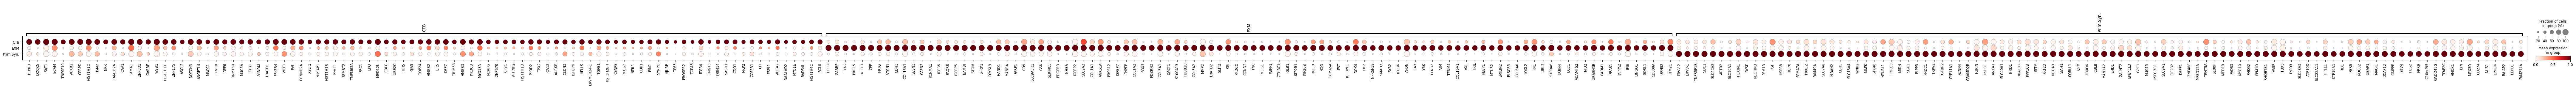

In [649]:
sc.pl.dotplot(ad6_coarse, marker_genes, groupby=cell_type_anno_col, standard_scale="var")
# "CTB": ["TP63", "ASCL2", "TEAD4", "CDH1", "EGFR", "PTGES", "TOP2A"]

In [587]:
coarse_summary_deg_df.groupby('group').apply(lambda x: x.names[0:10]).reset_index().to_dict('group')

/tmp/ipykernel_710357/2035028571.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  coarse_summary_deg_df.groupby('group').apply(lambda x: x.names[0:10]).reset_index().to_dict('group')


ValueError: orient 'group' not understood

In [577]:
coarse_summary_deg_df

,group,names,logfoldchanges_min,pvals_rank_max
0,EXM,TPM1,2.780179,2.0
1,Prim.Syn.,ERVV-2,4.884737,2.0
2,EXM,SPARC,2.569754,3.0
3,Prim.Syn.,ERVV-1,5.304142,4.0
4,EXM,TGFBI,6.497303,5.0
...,...,...,...,...
54241,Prim.Syn.,CNDP2,-4.627923,18082.0
54242,EXM,MBNL3,-3.675567,18082.0
54243,CTB,SPARC,-2.569754,18082.0
54244,CTB,ERVV-2,-4.884737,18082.0


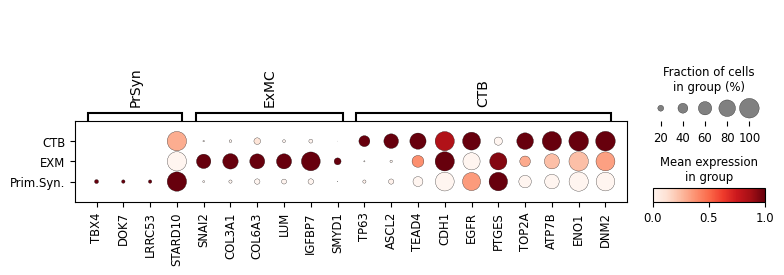

In [566]:
marker_genes = {
    "PrSyn": ["TBX4", "DOK7", "LRRC53", "STARD10"],
    "ExMC": ["SNAI2", "COL3A1", "COL6A3", "LUM", "IGFBP7", "SMYD1"],
    #"Cycling-Cell": ["MKI67", "CCNB1", "CENPF", "TOP2A", "CCNA2"],
    "CTB": ["TP63", "ASCL2", "TEAD4", "CDH1", "EGFR", "PTGES", "TOP2A", "ATP7B", "ENO1", "DNM2"]
}
sc.pl.dotplot(ad6_coarse, marker_genes, groupby=cell_type_anno_col, standard_scale="var")


In [253]:
#help(sc.tl.rank_genes_groups)

In [157]:
#help(sc.tl.rank_genes_groups)

In [206]:
dfs = [sc.get.rank_genes_groups_df(ad6_sub, group=None, key = 'rank_' + ct).assign(ref = ct) for ct in ad6_sub.obs[cell_type_anno_col].unique()]

In [254]:
deg_df = pd.concat(dfs, ignore_index=True)
deg_df

,group,names,scores,logfoldchanges,pvals,pvals_adj,ref
0,CTB,MBNL3,44.403587,3.675567,0.000000e+00,0.000000e+00,EXM
1,CTB,GATA2,43.818466,2.676947,0.000000e+00,0.000000e+00,EXM
2,CTB,ATP6V1C2,43.740967,4.446434,0.000000e+00,0.000000e+00,EXM
3,CTB,SYNE2,43.193771,2.534679,0.000000e+00,0.000000e+00,EXM
4,CTB,CSF3R,42.447174,3.363666,0.000000e+00,0.000000e+00,EXM
...,...,...,...,...,...,...,...
361635,Prim.Syn. Progenitor,NME4,-32.021008,-1.457812,5.562695e-225,2.579094e-222,Early Prim.Syn. Progenitor
361636,Prim.Syn. Progenitor,ERVMER34-1,-32.182507,-2.180113,3.101068e-227,1.602100e-224,Early Prim.Syn. Progenitor
361637,Prim.Syn. Progenitor,PHGDH,-32.761719,-1.456314,2.067686e-235,1.335282e-232,Early Prim.Syn. Progenitor
361638,Prim.Syn. Progenitor,MYH10,-34.028072,-1.858156,8.567543e-254,9.682394e-251,Early Prim.Syn. Progenitor


In [208]:
group = cell_type_anno_col
adata = ad6_sub
gene_by_cluster_stats = calculate_mean_expr_and_percent_expressed(ad6_sub, group)

/tmp/ipykernel_710357/964735670.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_obs = obs.groupby(level=0).mean().reset_index()
/tmp/ipykernel_710357/964735670.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraction_obs = (obs_bool.groupby(level=0).sum()/obs_bool.groupby(level=0).count()).reset_index()


In [211]:
gene_by_cluster_stats

,Annotated Cell Types,gene,pct_nz,mean_expr
0,CTB,SAMD11,0.129482,0.070769
1,EXM,SAMD11,0.310531,0.208260
2,Early Prim.Syn. Progenitor,SAMD11,0.057430,0.022947
3,Prim.Syn.,SAMD11,0.051163,0.008665
4,Prim.Syn. Progenitor,SAMD11,0.034659,0.011795
...,...,...,...,...
90405,CTB,MT-CYB,0.499502,0.402607
90406,EXM,MT-CYB,0.228623,0.147046
90407,Early Prim.Syn. Progenitor,MT-CYB,0.855707,0.904121
90408,Prim.Syn.,MT-CYB,0.818605,0.639659


In [255]:
tmp = gene_by_cluster_stats
tmp.columns = ['group', 'names', 'pct_nz_group', 'mean_expr_group']
deg_df = deg_df.merge(tmp)

tmp = gene_by_cluster_stats
tmp.columns = ['ref', 'names', 'pct_nz_ref', 'mean_expr_ref']
deg_df = deg_df.merge(tmp)
deg_df['pct_nz_group_minus_ref'] = deg_df['pct_nz_group'] - deg_df['pct_nz_ref']
deg_df['mean_expr_group_minus_ref'] = deg_df['mean_expr_group'] - deg_df['mean_expr_ref']

deg_df = deg_df.sort_values(by='pvals', ascending=True).reset_index()

In [256]:
deg_df[[x in ['PGF'] for x in deg_df.names]]

,index,group,names,scores,logfoldchanges,pvals,pvals_adj,ref,pct_nz_group,mean_expr_group,pct_nz_ref,mean_expr_ref,pct_nz_group_minus_ref,mean_expr_group_minus_ref
128,19,CTB,PGF,39.070217,2.696687,0.000000e+00,0.000000e+00,EXM,0.986056,2.170742,0.777678,0.787408,0.208378,1.383334
337,36164,Prim.Syn.,PGF,40.385845,6.132715,0.000000e+00,0.000000e+00,EXM,1.000000,4.443100,0.777678,0.787408,0.222322,3.655692
384,108491,EXM,PGF,-40.385845,-6.132715,0.000000e+00,0.000000e+00,Prim.Syn.,0.777678,0.787408,1.000000,4.443100,-0.222322,-3.655692
448,90390,CTB,PGF,-44.083416,-3.436027,0.000000e+00,0.000000e+00,Prim.Syn.,0.986056,2.170742,1.000000,4.443100,-0.013944,-2.272358
540,325517,Prim.Syn.,PGF,39.697495,2.572541,0.000000e+00,0.000000e+00,Early Prim.Syn. Progenitor,1.000000,4.443100,1.000000,2.716513,0.000000,1.726588
634,325464,EXM,PGF,-41.995499,-3.560174,0.000000e+00,0.000000e+00,Early Prim.Syn. Progenitor,0.777678,0.787408,1.000000,2.716513,-0.222322,-1.929105
654,198902,Prim.Syn. Progenitor,PGF,41.147591,2.566149,0.000000e+00,0.000000e+00,CTB,1.000000,3.849831,0.986056,2.170742,0.013944,1.679089
835,180839,Prim.Syn.,PGF,44.083416,3.436027,0.000000e+00,0.000000e+00,CTB,1.000000,4.443100,0.986056,2.170742,0.013944,2.272358
955,54246,Prim.Syn. Progenitor,PGF,39.454323,5.262837,0.000000e+00,0.000000e+00,EXM,1.000000,3.849831,0.777678,0.787408,0.222322,3.062423
1115,18093,Early Prim.Syn. Progenitor,PGF,41.995499,3.560174,0.000000e+00,0.000000e+00,EXM,1.000000,2.716513,0.777678,0.787408,0.222322,1.929105


In [264]:
tmp = deg_df
#tmp = tmp[[x > 0.95 for x in tmp.pct_nz_group]]
#tmp = tmp[[x < 0.2 for x in tmp.pct_nz_ref]]
#tmp = tmp[[x > 0 for x in tmp.logfoldchanges]]
#tmp = tmp[[x > 0.5 for x in tmp.pct_nz_group_minus_ref]]
tmp = tmp[[x < 10**-300 for x in tmp.pvals_adj]]
tmp.groupby(['group', 'ref']).size()
#tmp[[x in ['PGF'] for x in tmp.names]]

group                       ref                       
CTB                         EXM                           128
                            Early Prim.Syn. Progenitor     18
                            Prim.Syn.                     243
                            Prim.Syn. Progenitor           17
EXM                         CTB                           128
                            Early Prim.Syn. Progenitor    184
                            Prim.Syn.                     187
                            Prim.Syn. Progenitor           97
Early Prim.Syn. Progenitor  CTB                            18
                            EXM                           184
                            Prim.Syn.                     172
Prim.Syn.                   CTB                           243
                            EXM                           187
                            Early Prim.Syn. Progenitor    172
Prim.Syn. Progenitor        CTB                            17
               

In [317]:
deg_df[[gene in ['ASCL2', 'TP63'] and group in ['CTB'] for gene, group in zip(deg_df.names, deg_df.group)]]

,index,group,names,scores,logfoldchanges,pvals,pvals_adj,ref,pct_nz_group,mean_expr_group,pct_nz_ref,mean_expr_ref,pct_nz_group_minus_ref,mean_expr_group_minus_ref
8888,129,CTB,ASCL2,29.685581,4.933821,1.178770e-193,6.232315e-192,EXM,0.674801,0.723361,0.062106,0.034135,0.612695,0.689226
11454,72940,CTB,ASCL2,27.875380,4.517225,5.306099e-171,9.565791e-170,Prim.Syn.,0.674801,0.723361,0.171163,0.045307,0.503638,0.678054
26858,217295,CTB,ASCL2,20.725389,2.211021,2.044629e-95,5.050681e-94,Prim.Syn. Progenitor,0.674801,0.723361,0.312946,0.206389,0.361855,0.516971
27515,469,CTB,TP63,20.522150,5.228251,1.365359e-93,2.777100e-92,EXM,0.461155,0.339189,0.023402,0.010715,0.437753,0.328474
33697,74093,CTB,TP63,18.739714,4.598535,2.348875e-78,1.633552e-77,Prim.Syn.,0.461155,0.339189,0.089302,0.016530,0.371853,0.322658
33820,217422,CTB,TP63,18.705618,4.274350,4.455448e-78,8.339897e-77,Prim.Syn. Progenitor,0.461155,0.339189,0.060143,0.020653,0.401013,0.318536
49438,289721,CTB,ASCL2,15.210537,1.193713,3.010630e-52,3.581461e-51,Early Prim.Syn. Progenitor,0.674801,0.723361,0.505384,0.381170,0.169417,0.342191
101542,290332,CTB,TP63,8.349673,1.046648,6.845205e-17,3.064496e-16,Early Prim.Syn. Progenitor,0.461155,0.339189,0.378320,0.178548,0.082835,0.160641


In [316]:
deg_df[[group in ['CTB'] for gene, group in zip(deg_df.names, deg_df.group)]].sort_values(by='scores', ascending=False)

,index,group,names,scores,logfoldchanges,pvals,pvals_adj,ref,pct_nz_group,mean_expr_group,pct_nz_ref,mean_expr_ref,pct_nz_group_minus_ref,mean_expr_group_minus_ref
591,289312,CTB,WSB1,45.579624,1.889926,0.0,0.0,Early Prim.Syn. Progenitor,1.000000,2.868764,0.996411,1.701678,0.003589,1.167086
590,289313,CTB,SLC16A3,44.963146,2.845908,0.0,0.0,Early Prim.Syn. Progenitor,0.988546,2.009562,0.724336,0.641080,0.264210,1.368483
1466,72328,CTB,CNDP2,44.550354,4.042150,0.0,0.0,Prim.Syn.,0.997510,2.207588,0.660465,0.399644,0.337045,1.807944
1286,0,CTB,MBNL3,44.403587,3.675567,0.0,0.0,EXM,0.995518,2.223829,0.611161,0.497787,0.384357,1.726042
1285,1,CTB,GATA2,43.818466,2.676947,0.0,0.0,EXM,0.998506,2.571158,0.881188,1.060953,0.117318,1.510205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1671,18077,CTB,IGFBP2,-46.010704,-2.931770,0.0,0.0,EXM,0.982072,1.808766,1.000000,3.687317,-0.017928,-1.878551
1686,18078,CTB,TGFBI,-46.118744,-6.497303,0.0,0.0,EXM,0.435259,0.280980,0.999100,3.411441,-0.563841,-3.130461
1685,18079,CTB,GABRP,-46.172970,-4.947195,0.0,0.0,EXM,0.594622,0.481251,1.000000,2.999139,-0.405378,-2.517888
1684,18080,CTB,TPM1,-46.178867,-2.780179,0.0,0.0,EXM,1.000000,2.555626,1.000000,4.414055,0.000000,-1.858429


In [161]:
deg_df[[g == 'Prim.Syn.' and gn == 'GCM1' for g, gn in zip(deg_df.group, deg_df.names)]]

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,ref
36222,Prim.Syn.,GCM1,38.386353,5.216622,0.000000e+00,0.000000e+00,0.974884,EXM
181227,Prim.Syn.,GCM1,27.462254,1.611057,4.960621e-166,8.478066e-165,0.974884,CTB
285889,Prim.Syn.,GCM1,-9.154313,-0.476861,5.470477e-20,2.395669e-19,0.974884,Prim.Syn. Progenitor
326458,Prim.Syn.,GCM1,12.445156,0.510272,1.485936e-35,4.557105e-35,0.974884,Early Prim.Syn. Progenitor


In [335]:
tmp = deg_df
tmp = tmp[[ct in coarse_cell_types for ct in tmp.group]]
tmp = tmp[[ct in coarse_cell_types for ct in tmp.ref]]
summary_deg_df = tmp.groupby(['group', 'names']).agg(
    pvals_adj_max=pd.NamedAgg(column="pvals_adj", aggfunc="max"),
    scores_min=pd.NamedAgg(column="scores", aggfunc="min"),
    logfoldchanges_min=pd.NamedAgg(column="logfoldchanges", aggfunc="min"),
    #logfoldchanges_max=pd.NamedAgg(column="logfoldchanges", aggfunc="max")
    #pct_nz_group_min=pd.NamedAgg(column="pct_nz_group", aggfunc="min")
).reset_index()
summary_deg_df = summary_deg_df.sort_values(by = 'scores_min', ascending=False).reset_index(drop=True)

In [336]:
summary_deg_df[[x == 'CTB' for x in summary_deg_df.group]]

,group,names,pvals_adj_max,scores_min,logfoldchanges_min
78,CTB,BSG,0.000000e+00,38.534904,1.654907
82,CTB,ATP7B,0.000000e+00,38.477394,2.407833
145,CTB,PTPRU,1.901502e-291,36.600403,2.477593
156,CTB,ENO1,3.071016e-286,36.287502,1.388423
174,CTB,DOCK5,2.115722e-279,35.830616,3.657052
...,...,...,...,...,...
54241,CTB,IGFBP2,1.334311e-01,-46.010704,-2.931770
54242,CTB,TGFBI,1.608936e-21,-46.118744,-6.497303
54243,CTB,GABRP,5.041557e-19,-46.172970,-4.947195
54244,CTB,TPM1,0.000000e+00,-46.178867,-2.780179


In [312]:
marker_df = summary_deg_df
marker_df = marker_df[[x > 0 and y < 10**-5 for x, y in zip(summary_deg_df.logfoldchanges_min, summary_deg_df.pvals_adj_max)]]
print(marker_df.groupby('group').size())
marker_df

group
CTB                            678
EXM                           1290
Early Prim.Syn. Progenitor    2401
Prim.Syn.                     1036
Prim.Syn. Progenitor           321
dtype: int64


,group,names,pvals_adj_max,logfoldchanges_min
33,CTB,ABCA2,4.806851e-64,1.151418
62,CTB,ABCD4,2.070538e-21,0.558515
88,CTB,ABHD4,3.609499e-26,0.988073
139,CTB,AC118549.1,1.547715e-10,0.363426
160,CTB,ACADVL,2.042576e-42,0.332966
...,...,...,...,...
90100,Prim.Syn. Progenitor,ZNF513,4.943084e-13,0.480812
90204,Prim.Syn. Progenitor,ZNF655,2.676150e-21,0.395349
90271,Prim.Syn. Progenitor,ZNF750,5.013652e-30,0.801080
90353,Prim.Syn. Progenitor,ZNRF1,1.687453e-13,0.390357


In [268]:
marker_df = summary_deg_df[[x > 0 and y < 0.05 for x, y in zip(summary_deg_df.logfoldchanges_max, summary_deg_df.pvals_adj_max)]]
marker_df = marker_df[[x > 0.9 for x in marker_df.pct_nz_group_min]]
marker_df = marker_df.sort_values(by='logfoldchanges_max', ascending=False).reset_index()
marker_df.groupby('group').size()

group
CTB                            592
EXM                            513
Early Prim.Syn. Progenitor    1331
Prim.Syn.                      782
Prim.Syn. Progenitor          1119
dtype: int64

In [277]:
marker_df

,group,names,pvals_adj_max,logfoldchanges_max,pct_nz_group_min
18316,EXM,ACTC1,0.000000e+00,6.486145,0.996400
18843,EXM,ANKS1A,0.000000e+00,3.673130,0.999100
19499,EXM,BAMBI,0.000000e+00,6.031209,0.988299
20263,EXM,CAPN2,0.000000e+00,5.112694,1.000000
20701,EXM,CD99,6.235814e-303,2.992824,1.000000
20763,EXM,CDH3,0.000000e+00,6.097420,0.987399
21407,EXM,COL18A1,0.000000e+00,5.250971,1.000000
21538,EXM,CPE,0.000000e+00,6.547699,0.993699
22489,EXM,DPYSL3,0.000000e+00,7.781773,0.969397
23385,EXM,FARP1,0.000000e+00,6.368134,0.964896


/projects/compsci/jgeorge/whitebr/miniforge3/envs/napari-env/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='pvals', ylabel='Count'>

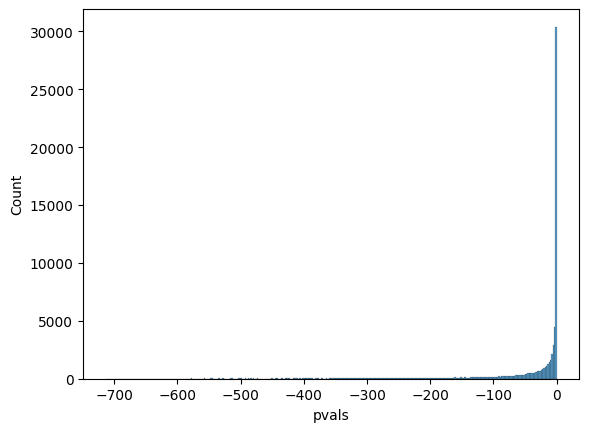

In [285]:
import seaborn as sns
ct = 'Prim.Syn.'
ct = 'EXM'
sns.histplot(x = np.log(deg_df[[x == ct for x in deg_df.group]].pvals))

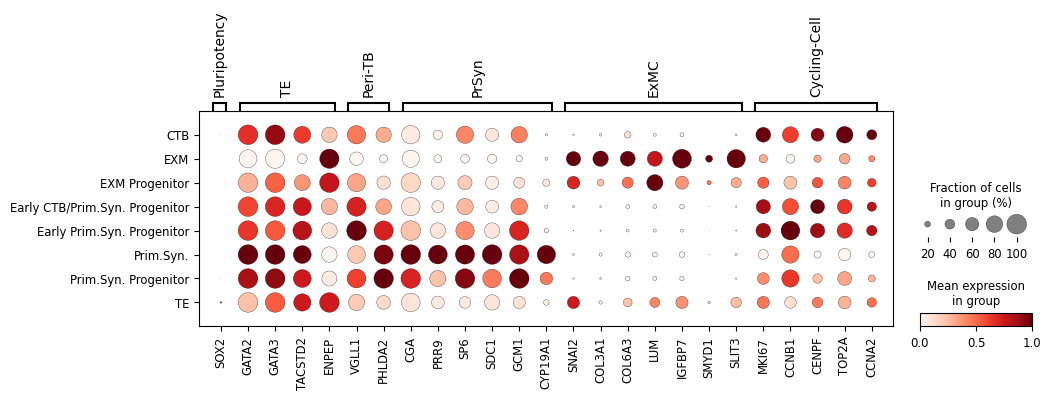

In [167]:
marker_genes = {
    #"Pluripotency": ["SOX2"],
    #"TE": ["GATA2", "GATA3", "TACSTD2", "ENPEP"],
    "Peri-TB": ["VGLL1", "PHLDA2"],
    "PrSyn": ["CGA", "PRR9", "SP6", "SDC1", "GCM1", "CYP19A1"],
    "ExMC": ["SNAI2", "COL3A1", "COL6A3", "LUM", "IGFBP7", "SMYD1", "SLIT3"],
    #"Cycling-Cell": ["MKI67", "CCNB1", "CENPF", "TOP2A", "CCNA2"]
    "CTB": ["TP63", "ASCL2", "TEAD4", "CDH1", "EGFR", ]
}
sc.pl.dotplot(ad6, marker_genes, groupby=cell_type_anno_col, standard_scale="var")


In [202]:
def calculate_mean_expr_and_percent_expressed(adata, group):
    # See https://github.com/scverse/scanpy/issues/336
    gene_ids = adata.raw.var.index.values
    clusters = adata.obs[group].cat.categories
    obs = adata.raw[:,gene_ids].X.toarray()
    obs = pd.DataFrame(obs,columns=gene_ids,index=adata.obs[group])
    average_obs = obs.groupby(level=0).mean().reset_index()
    obs_bool = obs.astype(bool)
    fraction_obs = (obs_bool.groupby(level=0).sum()/obs_bool.groupby(level=0).count()).reset_index()
    average_obs = pd.melt(average_obs, id_vars = group)
    average_obs.columns = [group, 'gene', 'mean_expr']
    fraction_obs = pd.melt(fraction_obs, id_vars = group)
    fraction_obs.columns = [group, 'gene', 'pct_nz']
    return fraction_obs.merge(average_obs)

In [203]:
group = cell_type_anno_col
adata = ad6_sub
gene_by_cluster_stats = calculate_mean_expr_and_percent_expressed(ad6_sub, group)

/tmp/ipykernel_710357/964735670.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_obs = obs.groupby(level=0).mean().reset_index()
/tmp/ipykernel_710357/964735670.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraction_obs = (obs_bool.groupby(level=0).sum()/obs_bool.groupby(level=0).count()).reset_index()


In [204]:
gene_by_cluster_stats

,Annotated Cell Types,gene,pct_nz,mean_expr
0,CTB,SAMD11,0.129482,0.070769
1,EXM,SAMD11,0.310531,0.208260
2,Early Prim.Syn. Progenitor,SAMD11,0.057430,0.022947
3,Prim.Syn.,SAMD11,0.051163,0.008665
4,Prim.Syn. Progenitor,SAMD11,0.034659,0.011795
...,...,...,...,...
90405,CTB,MT-CYB,0.499502,0.402607
90406,EXM,MT-CYB,0.228623,0.147046
90407,Early Prim.Syn. Progenitor,MT-CYB,0.855707,0.904121
90408,Prim.Syn.,MT-CYB,0.818605,0.639659


In [201]:
fraction_obs.merge(average_obs)

,Annotated Cell Types,gene,pct_nz,mean_expr
0,CTB,SAMD11,0.129482,0.070769
1,EXM,SAMD11,0.310531,0.208260
2,Early Prim.Syn. Progenitor,SAMD11,0.057430,0.022947
3,Prim.Syn.,SAMD11,0.051163,0.008665
4,Prim.Syn. Progenitor,SAMD11,0.034659,0.011795
...,...,...,...,...
90405,CTB,MT-CYB,0.499502,0.402607
90406,EXM,MT-CYB,0.228623,0.147046
90407,Early Prim.Syn. Progenitor,MT-CYB,0.855707,0.904121
90408,Prim.Syn.,MT-CYB,0.818605,0.639659


In [197]:
fraction_obs.columns

Index(['Annotated Cell Types', 'SAMD11', 'NOC2L', 'KLHL17', 'PLEKHN1', 'PERM1',
       'HES4', 'ISG15', 'AGRN', 'RNF223',
       ...
       'MT-ND2', 'MT-CO2', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4',
       'MT-ND5', 'MT-ND6', 'MT-CYB'],
      dtype='object', length=18083)

In [198]:
pd.melt(average_obs, id_vars = group).columns

Index(['Annotated Cell Types', 'variable', 'value'], dtype='object')

In [195]:
pd.melt(fraction_obs, id_vars=group)

,Annotated Cell Types,variable,value
0,CTB,index,0.000000
1,EXM,index,1.000000
2,Early Prim.Syn. Progenitor,index,2.000000
3,Prim.Syn.,index,3.000000
4,Prim.Syn. Progenitor,index,4.000000
...,...,...,...
90410,CTB,MT-CYB,0.499502
90411,EXM,MT-CYB,0.228623
90412,Early Prim.Syn. Progenitor,MT-CYB,0.855707
90413,Prim.Syn.,MT-CYB,0.818605


In [187]:
pd.melt(fraction_obs, id_vars = group)

,Annotated Cell Types,variable,value
0,NaN,A1CF,NaN
1,NaN,A1CF,NaN
2,NaN,A1CF,NaN
3,NaN,A1CF,NaN
4,NaN,A1CF,NaN
...,...,...,...
180815,NaN,ZZEF1,NaN
180816,NaN,ZZEF1,NaN
180817,NaN,ZZEF1,NaN
180818,NaN,ZZEF1,NaN


In [176]:
genedf = sc.get.obs_df(ad6_sub, keys=[cell_type_anno_col, *ad6_sub.var_names])
grouped = genedf.groupby(cell_type_anno_col, observed=True)
mean, var = grouped.mean(), grouped.var()

In [174]:
var

,SAMD11,HES4,ISG15,RNF223,TAS1R3,ANKRD65,VWA1,ATAD3C,PRKCZ,HES5,...,MT-ND1,MT-ND2,MT-CO2,MT-ATP6,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB
Annotated Cell Types,,,,,,,,,,,,,,,,,,,,,
CTB,1.642241,1.890272,2.036925,1.651662,0.878099,1.778163,1.156186,1.549113,1.184713,0.309522,...,1.754939,1.860136,2.263624,1.912010,1.984365,1.715646,1.560418,1.792018,1.489204,2.313470
EXM,0.899729,0.640193,0.831002,1.414147,0.342031,0.540032,0.963022,0.955107,0.801913,0.056569,...,0.549259,0.514576,1.716682,1.272543,0.547112,1.099219,1.566098,0.414638,0.972718,1.024093
Early Prim.Syn. Progenitor,0.792011,1.157009,1.089182,0.600177,0.609690,0.965376,2.167818,1.248119,1.479185,0.316537,...,1.393509,1.397081,1.850293,1.791250,1.533104,1.677598,1.485969,1.632866,0.972695,1.414092
Prim.Syn.,0.063443,0.203789,0.480132,0.274579,0.345209,0.297968,0.523217,0.685954,0.220534,0.477774,...,0.153655,0.166393,0.641108,0.535012,0.278007,0.386243,0.621024,0.178957,0.339206,0.310045
Prim.Syn. Progenitor,0.537190,0.991004,1.124756,0.952859,0.556469,1.091169,0.482473,1.210637,0.413500,0.557552,...,0.981676,0.947255,0.930623,1.001221,1.038695,0.857528,1.026782,0.993705,1.383483,1.160489


In [243]:
#help(sc.pl.dotplot)

In [104]:
ct = 'Prim.Syn.'
sc.tl.rank_genes_groups(ad6_sub, groupby=cell_type_anno_col, method="wilcoxon", rankby_abs = False, reference = ct, key_added = 'rank_' + ct)

In [149]:
#help(sc.get.rank_genes_groups_df)

In [123]:
df = sc.get.rank_genes_groups_df(ad6_sub, group=None, key = 'rank_' + ct)

In [125]:
df.assign(ref = ct)

,group,names,scores,logfoldchanges,pvals,pvals_adj,ref
0,CTB,WSB1,45.579624,1.889926,0.000000e+00,0.000000e+00,Early Prim.Syn. Progenitor
1,CTB,SLC16A3,44.963146,2.845908,0.000000e+00,0.000000e+00,Early Prim.Syn. Progenitor
2,CTB,SLC2A1,42.431194,1.473899,0.000000e+00,0.000000e+00,Early Prim.Syn. Progenitor
3,CTB,DSP,42.422619,1.345790,0.000000e+00,0.000000e+00,Early Prim.Syn. Progenitor
4,CTB,IGFBP3,41.632069,3.032139,0.000000e+00,0.000000e+00,Early Prim.Syn. Progenitor
...,...,...,...,...,...,...,...
72323,Prim.Syn. Progenitor,NME4,-32.021008,-1.457812,5.562695e-225,2.579094e-222,Early Prim.Syn. Progenitor
72324,Prim.Syn. Progenitor,ERVMER34-1,-32.182507,-2.180113,3.101068e-227,1.602100e-224,Early Prim.Syn. Progenitor
72325,Prim.Syn. Progenitor,PHGDH,-32.761719,-1.456314,2.067686e-235,1.335282e-232,Early Prim.Syn. Progenitor
72326,Prim.Syn. Progenitor,MYH10,-34.028072,-1.858156,8.567543e-254,9.682394e-251,Early Prim.Syn. Progenitor


In [117]:
sc.get.rank_genes_groups_df(ad6_sub, group=None, key = 'rank_' + ct)

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,CTB,WSB1,45.579624,1.889926,0.000000e+00,0.000000e+00
1,CTB,SLC16A3,44.963146,2.845908,0.000000e+00,0.000000e+00
2,CTB,SLC2A1,42.431194,1.473899,0.000000e+00,0.000000e+00
3,CTB,DSP,42.422619,1.345790,0.000000e+00,0.000000e+00
4,CTB,IGFBP3,41.632069,3.032139,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...
72323,Prim.Syn. Progenitor,NME4,-32.021008,-1.457812,5.562695e-225,2.579094e-222
72324,Prim.Syn. Progenitor,ERVMER34-1,-32.182507,-2.180113,3.101068e-227,1.602100e-224
72325,Prim.Syn. Progenitor,PHGDH,-32.761719,-1.456314,2.067686e-235,1.335282e-232
72326,Prim.Syn. Progenitor,MYH10,-34.028072,-1.858156,8.567543e-254,9.682394e-251


In [107]:
df = sc.get.rank_genes_groups_df(ad6_sub, group=None, key = 'rank_' + ct)

In [242]:
help(sc.get.rank_genes_groups_df)

Help on function rank_genes_groups_df in module scanpy.get.get:

rank_genes_groups_df(adata: 'AnnData', group: 'str | Iterable[str] | None', *, key: 'str' = 'rank_genes_groups', pval_cutoff: 'float | None' = None, log2fc_min: 'float | None' = None, log2fc_max: 'float | None' = None, gene_symbols: 'str | None' = None) -> 'pd.DataFrame'
    :func:`scanpy.tl.rank_genes_groups` results in the form of a
    :class:`~pandas.DataFrame`.

    Params
    ------
    adata
        Object to get results from.
    group
        Which group (as in :func:`scanpy.tl.rank_genes_groups`'s `groupby`
        argument) to return results from. Can be a list. All groups are
        returned if groups is `None`.
    key
        Key differential expression groups were stored under.
    pval_cutoff
        Return only adjusted p-values below the  cutoff.
    log2fc_min
        Minimum logfc to return.
    log2fc_max
        Maximum logfc to return.
    gene_symbols
        Column name in `.var` DataFrame that s

In [109]:
df[[x in ['SDC1', 'ERVV-2', 'ERVV-1', 'NECTIN3', 'GCM1'] for x in df.names]]

,group,names,scores,logfoldchanges,pvals,pvals_adj
17674,CTB,GCM1,-27.462254,-1.611057,4.960621e-166,8.478066e-165
18071,CTB,NECTIN3,-44.766289,-3.740433,0.000000e+00,0.000000e+00
18076,CTB,SDC1,-45.160351,-5.353937,0.000000e+00,0.000000e+00
18080,CTB,ERVV-1,-45.496906,-5.304142,0.000000e+00,0.000000e+00
18081,CTB,ERVV-2,-45.517925,-4.884737,0.000000e+00,0.000000e+00
36105,EXM,GCM1,-38.386353,-5.216622,0.000000e+00,0.000000e+00
36148,EXM,NECTIN3,-39.917107,-4.567725,0.000000e+00,0.000000e+00
36157,EXM,SDC1,-40.176640,-6.579266,0.000000e+00,0.000000e+00
36160,EXM,ERVV-1,-40.322945,-6.631441,0.000000e+00,0.000000e+00
36162,EXM,ERVV-2,-40.357105,-5.762256,0.000000e+00,0.000000e+00


In [355]:
ad6_sub.obs['subgroup'] = 0

In [366]:
[random.choice([1,2,3]) for k in np.arange(6)]

[3, 2, 3, 3, 2, 3]

In [363]:
help(random.sample)

Help on method sample in module random:

sample(population, k, *, counts=None) method of random.Random instance
    Chooses k unique random elements from a population sequence.

    Returns a new list containing elements from the population while
    leaving the original population unchanged.  The resulting list is
    in selection order so that all sub-slices will also be valid random
    samples.  This allows raffle winners (the sample) to be partitioned
    into grand prize and second place winners (the subslices).

    Members of the population need not be hashable or unique.  If the
    population contains repeats, then each occurrence is a possible
    selection in the sample.

    Repeated elements can be specified one at a time or with the optional
    counts parameter.  For example:

        sample(['red', 'blue'], counts=[4, 2], k=5)

    is equivalent to:

        sample(['red', 'red', 'red', 'red', 'blue', 'blue'], k=5)

    To choose a sample from a range of integers, use 

In [395]:
obs = ad6_sub.obs.copy()
obs['subgroup'] = 0
for ct in np.unique(obs[cell_type_anno_col]):
    tmp = obs[[x == ct for x in obs[cell_type_anno_col]]]
    samp = [random.choice([1,2,3]) for k in np.arange(len(tmp))]
    obs.loc[[x == ct for x in obs[cell_type_anno_col]],'subgroup'] = samp
obs['id'] = obs[cell_type_anno_col].astype(str) + '-' + obs['subgroup'].astype(str)

In [396]:
obs.id.values

array(['EXM-2', 'Prim.Syn.-3', 'CTB-2', ..., 'Prim.Syn. Progenitor-2',
       'Prim.Syn.-2', 'Early Prim.Syn. Progenitor-3'], dtype=object)

In [384]:
obs.groupby([cell_type_anno_col, 'subgroup']).size()

/tmp/ipykernel_710357/2739398390.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs.groupby(['Annotated Cell Types', 'subgroup']).size()


Annotated Cell Types        subgroup
CTB                         1           666
                            2           696
                            3           646
EXM                         1           364
                            2           367
                            3           380
Early Prim.Syn. Progenitor  1           497
                            2           455
                            3           441
Prim.Syn.                   1           366
                            2           387
                            3           322
Prim.Syn. Progenitor        1           283
                            2           338
                            3           360
dtype: int64

In [354]:
random.sample([1,2,3],3)

[3, 1, 2]

In [294]:
#help(sc.pl.rank_genes_groups)

In [298]:
ad6_sub.obs.groupby([cell_type_anno_col]).size()

/tmp/ipykernel_710357/3794860971.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ad6_sub.obs.groupby(['Annotated Cell Types']).size()


Annotated Cell Types
CTB                           2008
EXM                           1111
Early Prim.Syn. Progenitor    1393
Prim.Syn.                     1075
Prim.Syn. Progenitor           981
dtype: int64

{'params': {'groupby': 'Annotated Cell Types',
  'reference': 'EXM',
  'method': 'wilcoxon',
  'use_raw': True,
  'layer': None,
  'corr_method': 'benjamini-hochberg'},
 'names': rec.array([('MBNL3', 'PGF'), ('GATA2', 'ERVV-2'), ('ATP6V1C2', 'FHDC1'),
            ..., ('GABRP', 'SPARC'), ('TPM1', 'TPM1'), ('SPARC', 'MDK')],
           dtype=[('CTB', 'O'), ('Prim.Syn.', 'O')]),
 'scores': rec.array([( 44.403587,  40.385845), ( 43.818466,  40.357105),
            ( 43.740967,  40.351173), ..., (-46.17297 , -40.39025 ),
            (-46.178867, -40.40889 ), (-46.239075, -40.43417 )],
           dtype=[('CTB', '<f4'), ('Prim.Syn.', '<f4')]),
 'pvals': rec.array([(0., 0.), (0., 0.), (0., 0.), ..., (0., 0.), (0., 0.),
            (0., 0.)],
           dtype=[('CTB', '<f8'), ('Prim.Syn.', '<f8')]),
 'pvals_adj': rec.array([(0., 0.), (0., 0.), (0., 0.), ..., (0., 0.), (0., 0.),
            (0., 0.)],
           dtype=[('CTB', '<f8'), ('Prim.Syn.', '<f8')]),
 'logfoldchanges': rec.array([( 3.67

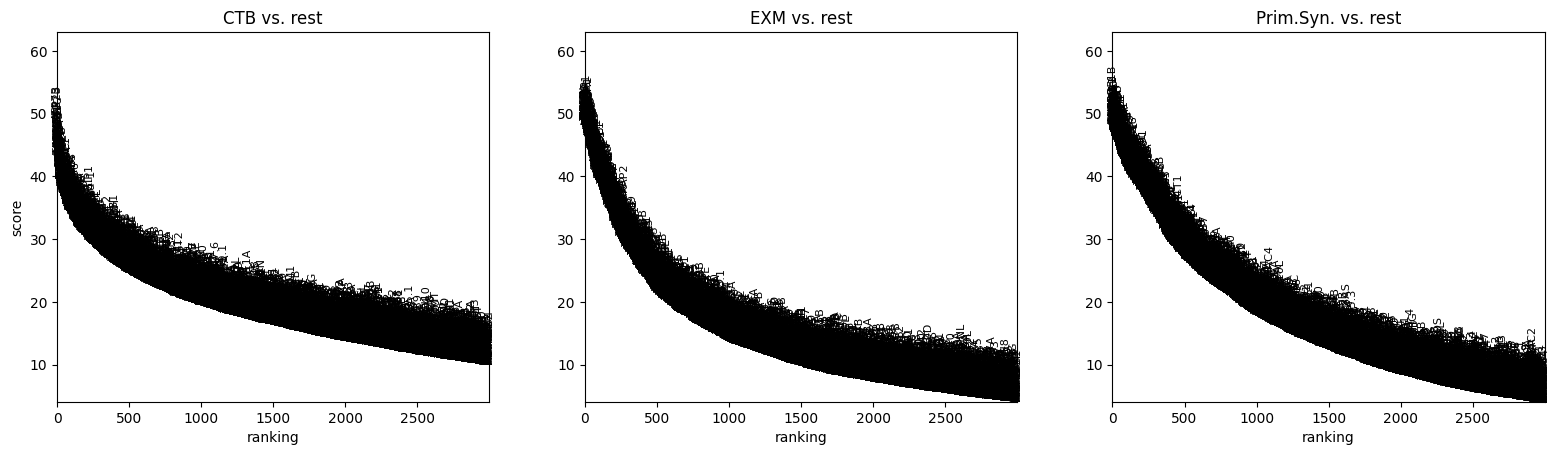

In [461]:
sc.pl.rank_genes_groups(ad6_coarse,n_genes=3000)

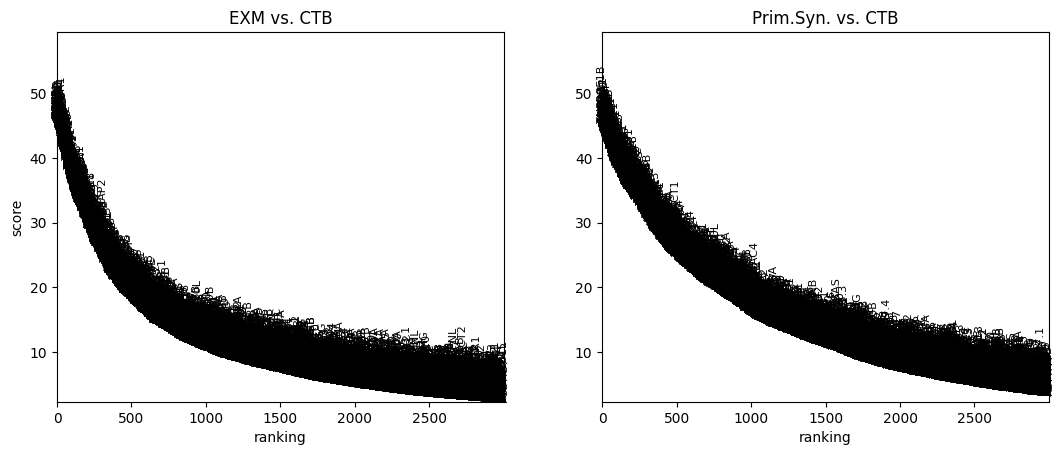

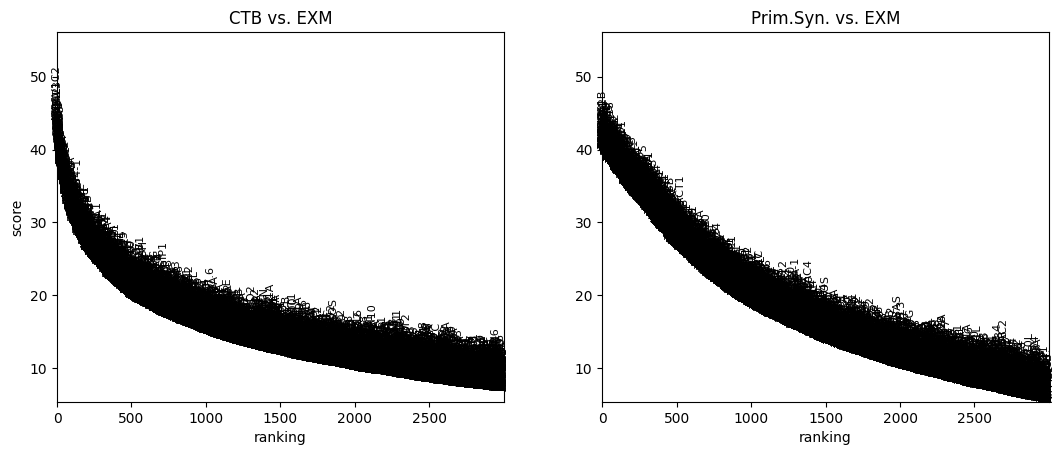

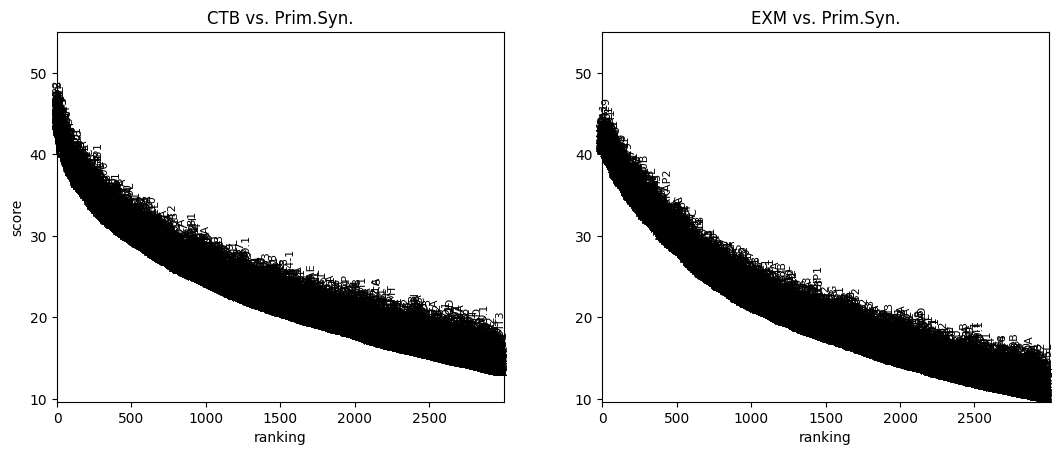

In [466]:
for ct in np.unique(ad6_coarse.obs[cell_type_anno_col]):
    sc.pl.rank_genes_groups(ad6_coarse,n_genes=3000,key='rank_' + ct)

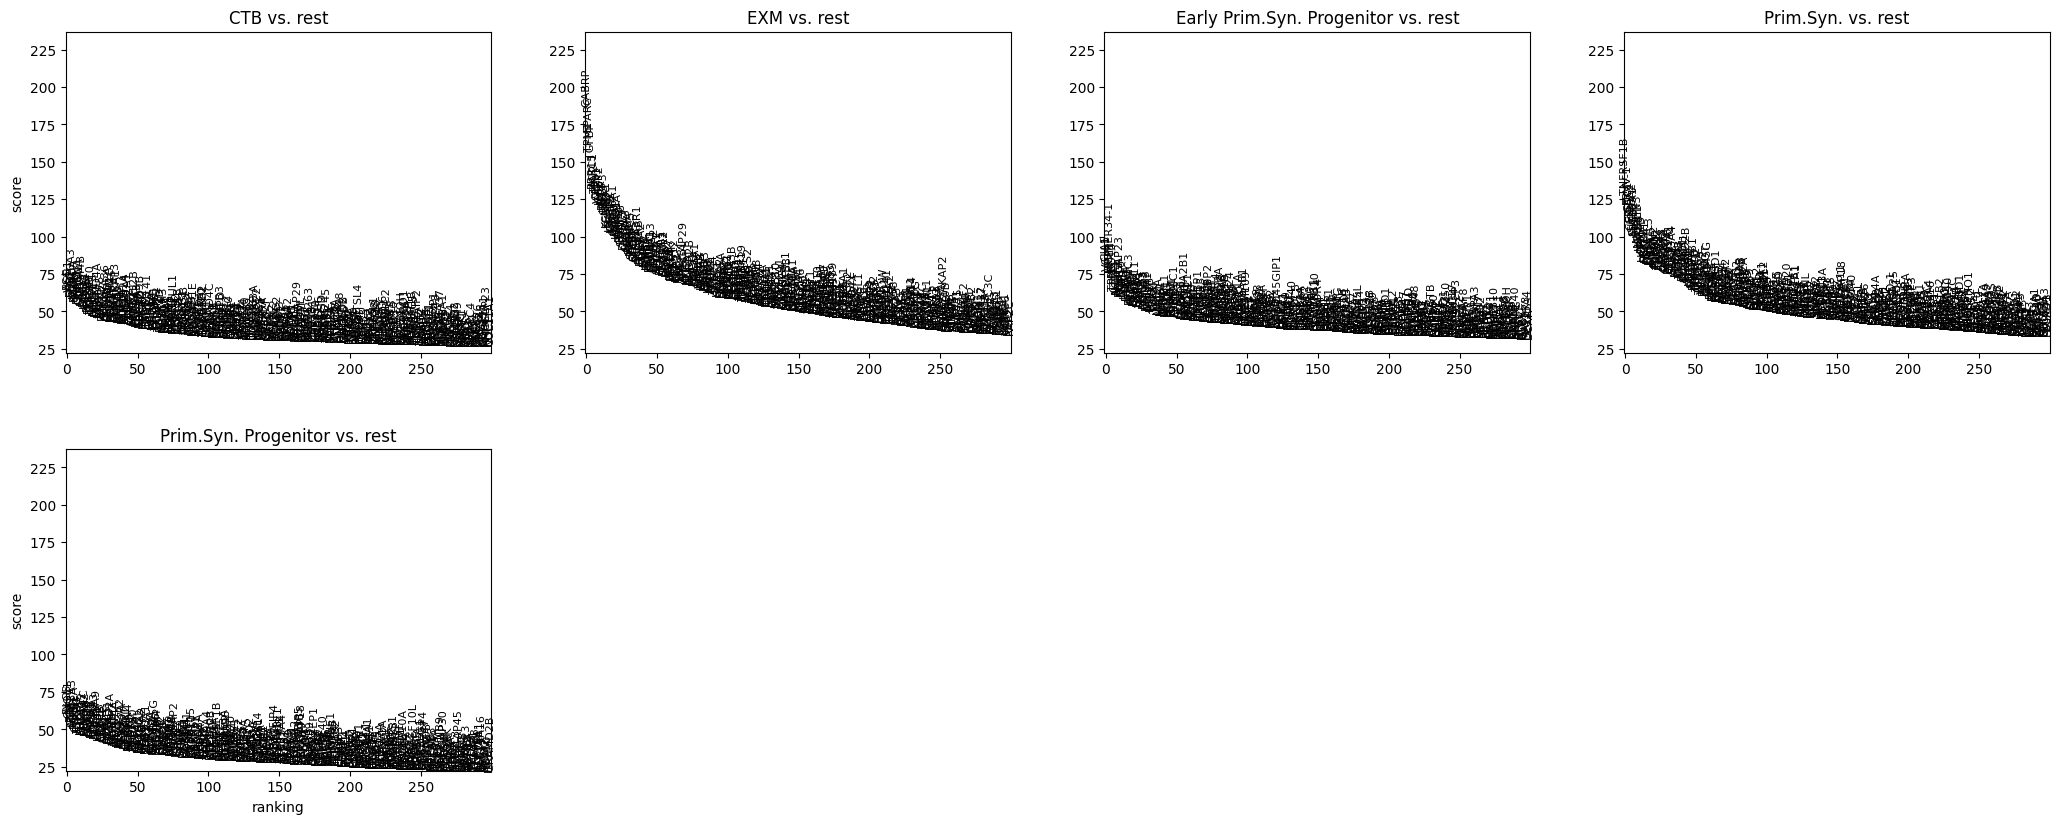

In [291]:
sc.pl.rank_genes_groups(ad6_sub,n_genes=300)

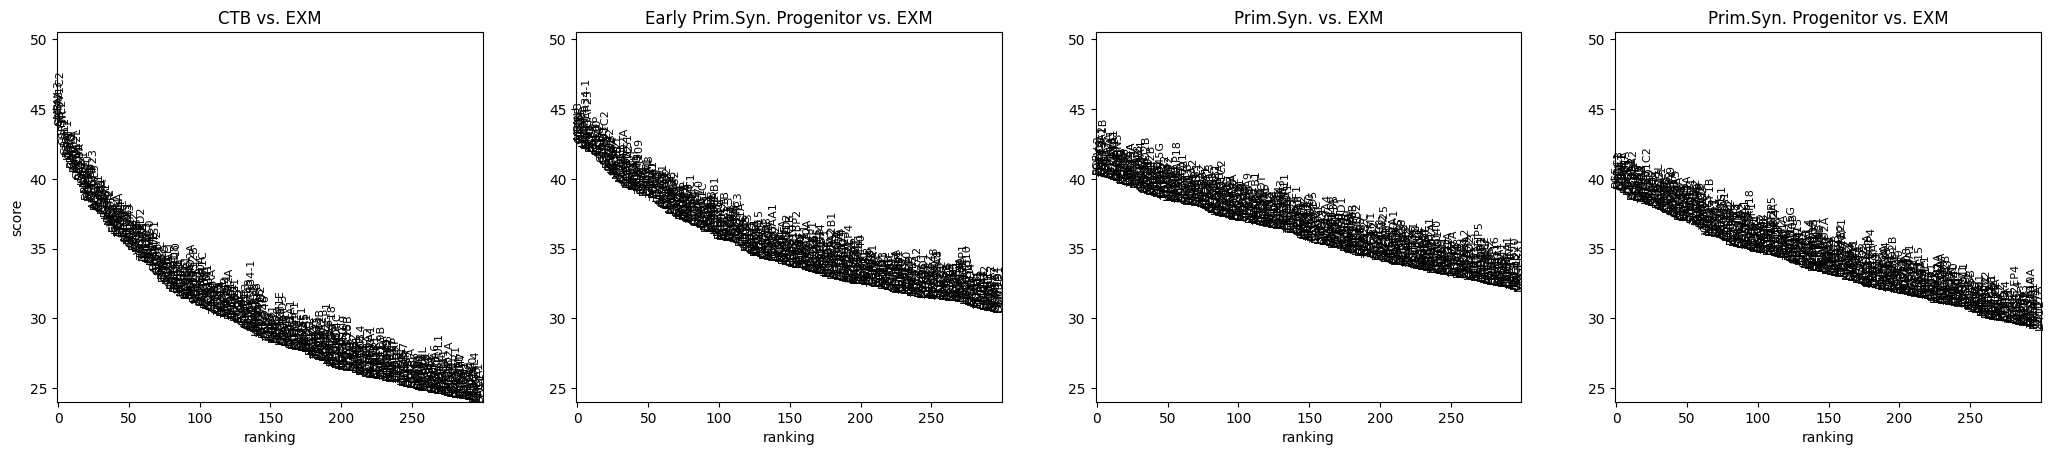

In [292]:
sc.pl.rank_genes_groups(ad6_sub,n_genes=300,key='rank_EXM')

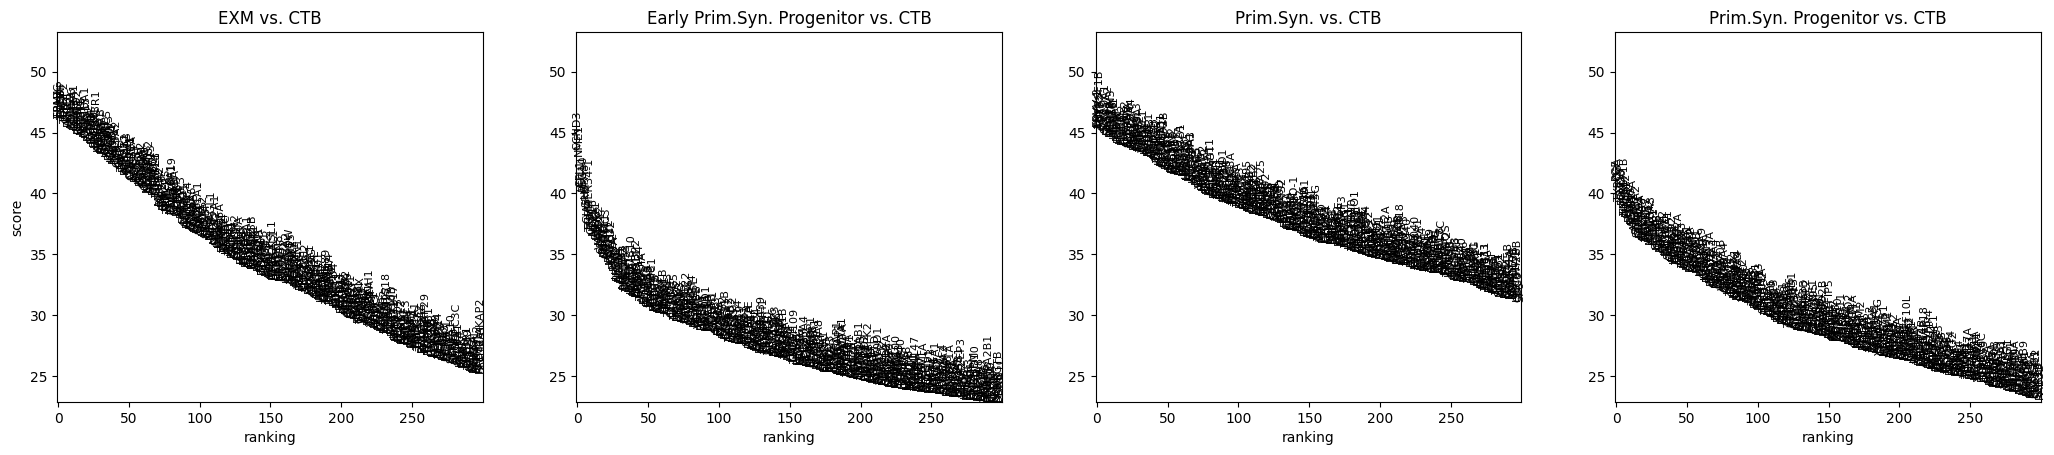

In [299]:
sc.pl.rank_genes_groups(ad6_sub,n_genes=300,key='rank_CTB')

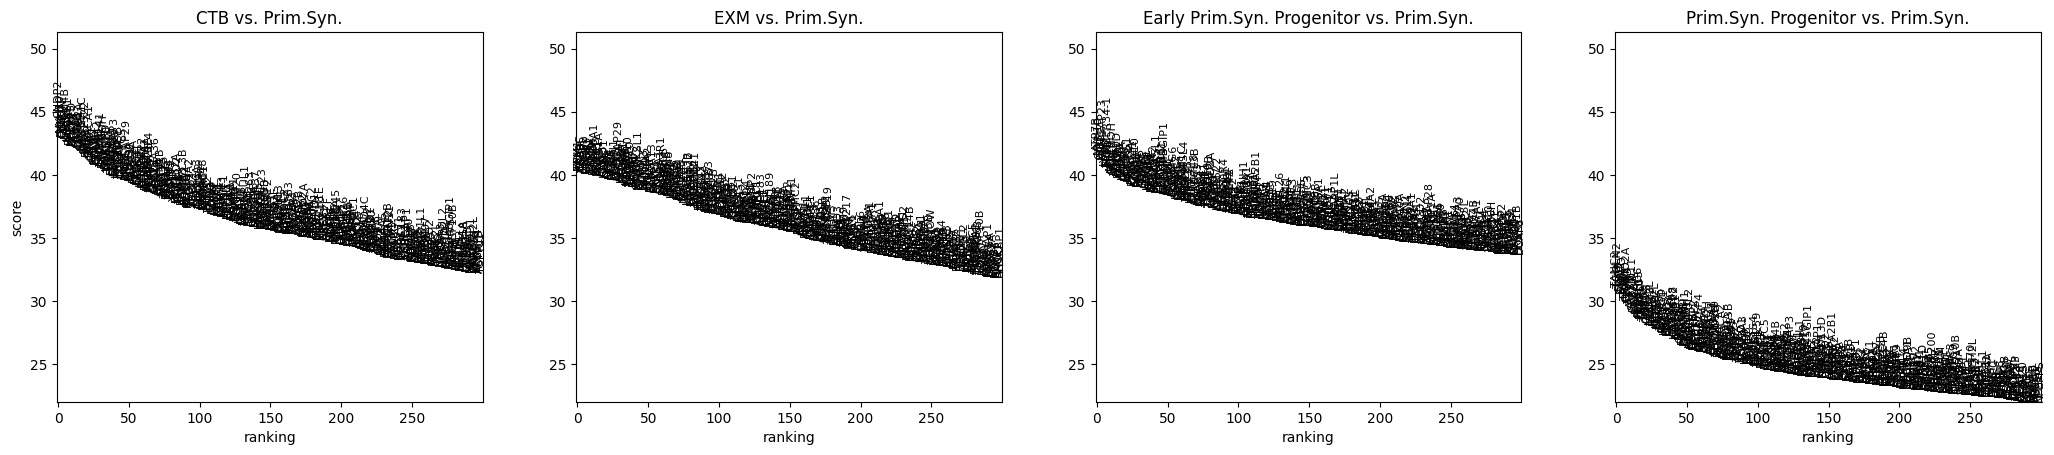

In [290]:
sc.pl.rank_genes_groups(ad6_sub,n_genes=300,key='rank_Prim.Syn.')

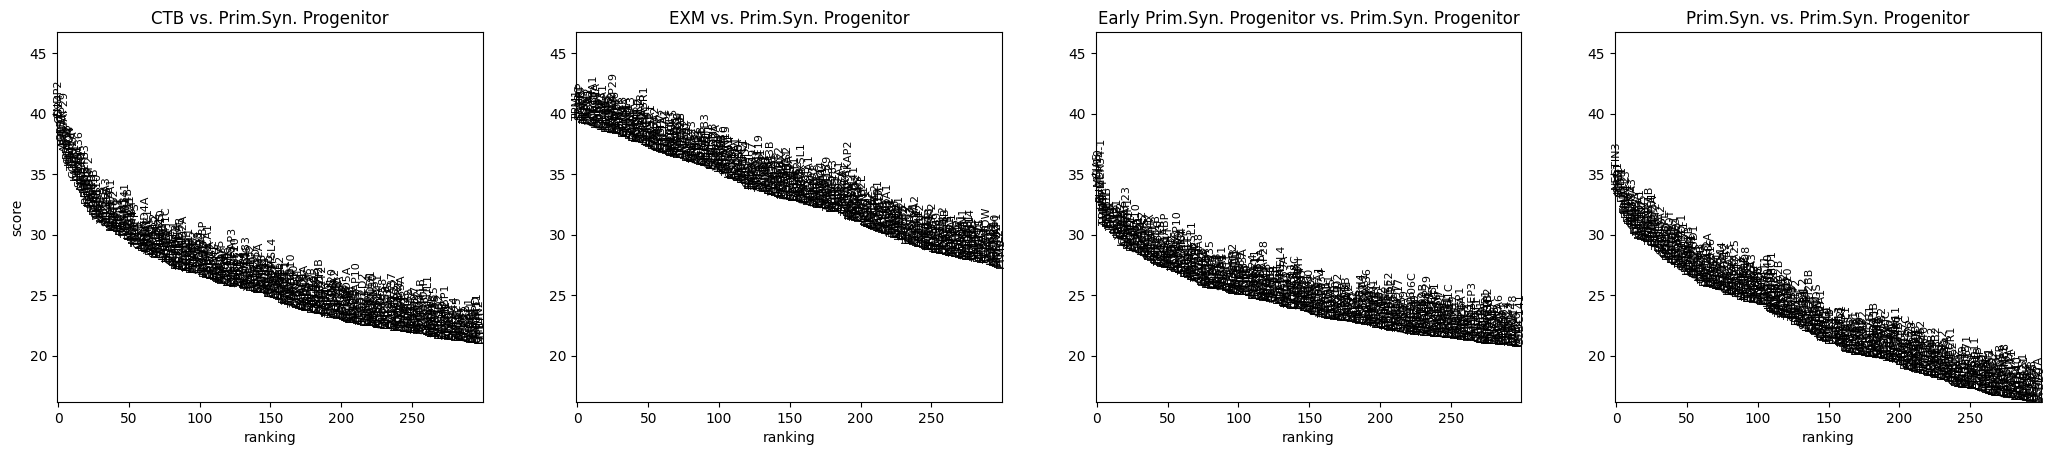

In [300]:
sc.pl.rank_genes_groups(ad6_sub,n_genes=300,key='rank_Prim.Syn. Progenitor')

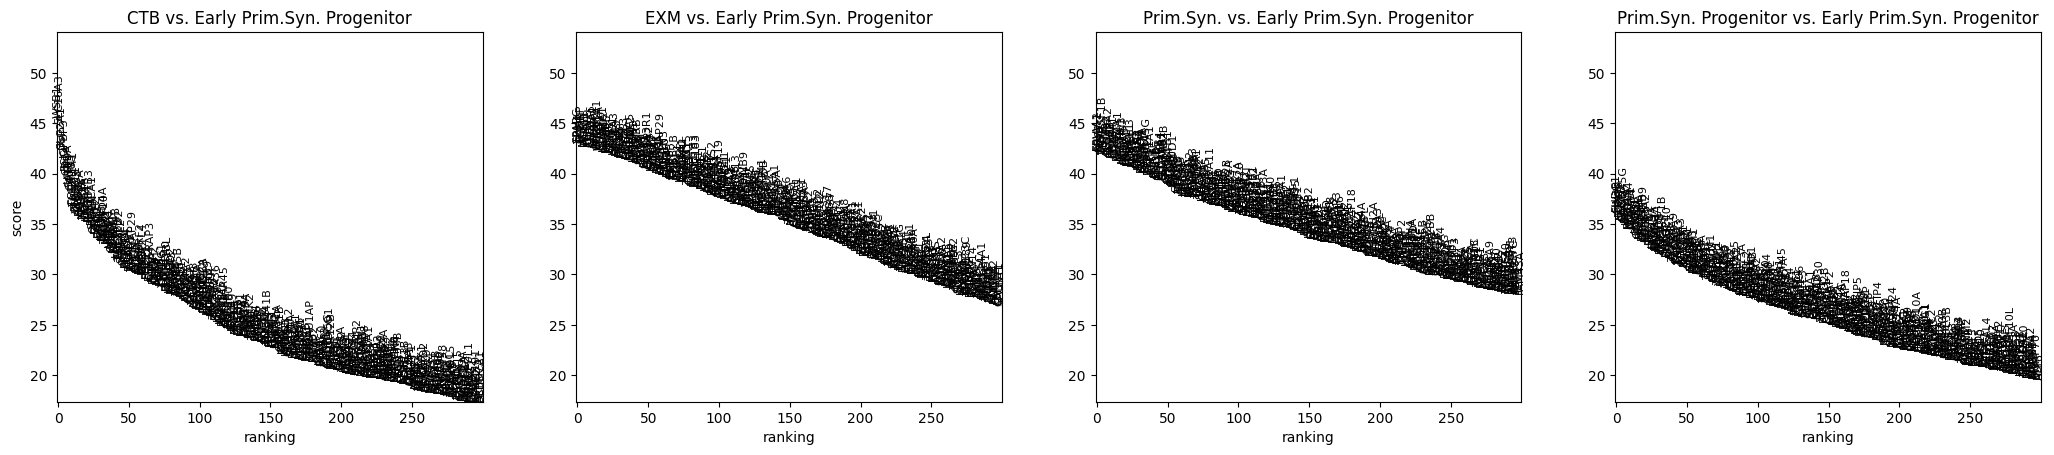

In [301]:
sc.pl.rank_genes_groups(ad6_sub,n_genes=300,key='rank_Early Prim.Syn. Progenitor')

In [103]:
ct = 'Prim.Syn.'
sc.tl.rank_genes_groups(ad6, groupby=cell_type_anno_col, method="wilcoxon", rankby_abs = False, reference = ct, key_added = 'rank_' + ct)

In [150]:
#help(sc.tl.rank_genes_groups)

In [241]:
df = sc.get.rank_genes_groups_df(ad6_sub, group = None)
df

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,CTB,BSG,65.310883,1.376016,0.000000e+00,0.000000e+00
1,CTB,WSB1,63.529888,1.466844,0.000000e+00,0.000000e+00
2,CTB,FHL2,60.928596,1.694619,0.000000e+00,0.000000e+00
3,CTB,SLC16A3,60.300568,1.828763,0.000000e+00,0.000000e+00
4,CTB,HILPDA,59.416542,1.905018,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...
90405,Prim.Syn. Progenitor,HAND1,-43.749477,-2.868474,0.000000e+00,0.000000e+00
90406,Prim.Syn. Progenitor,CD24,-43.782566,-1.872804,2.737654e-290,1.596847e-287
90407,Prim.Syn. Progenitor,DLC1,-45.483868,-3.121000,0.000000e+00,0.000000e+00
90408,Prim.Syn. Progenitor,MARCKS,-46.812592,-2.466766,0.000000e+00,0.000000e+00


In [237]:
ad6_sub.obs['rank_genes_groups']

KeyError: 'rank_genes_groups'

In [151]:
#help(sc.pl.rank_genes_groups_dotplot)

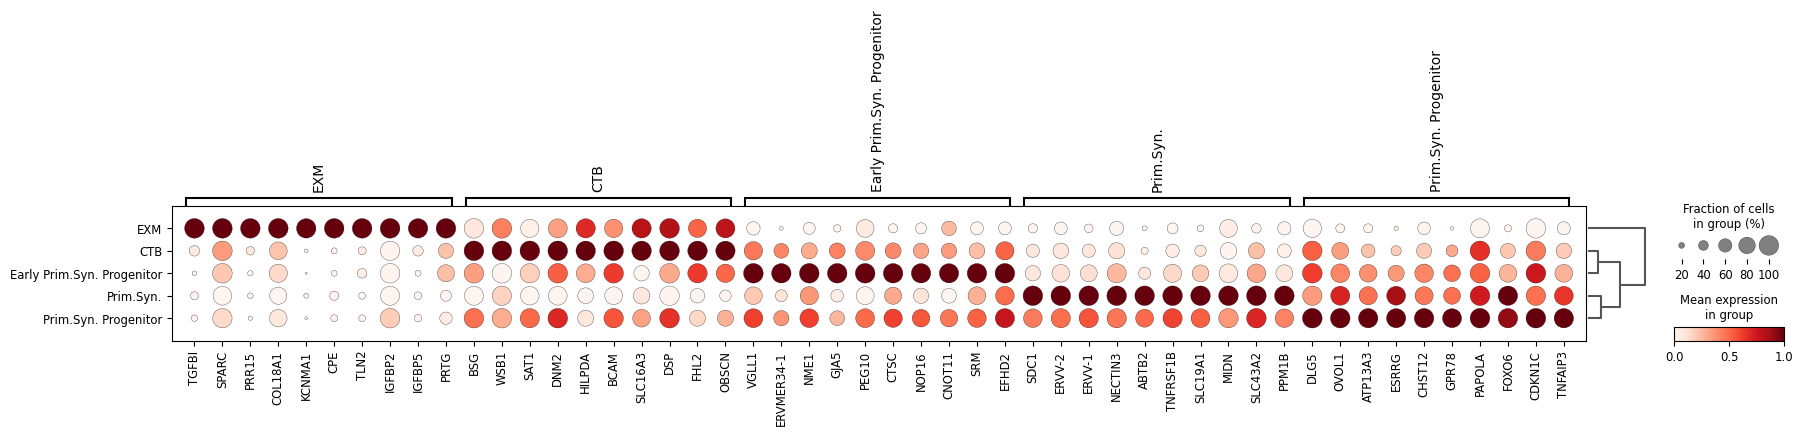

In [95]:
#sc.tl.dendrogram(ad6_sub, groupby=cell_type_anno_col)
sc.pl.rank_genes_groups_dotplot(
    ad6_sub, groupby=cell_type_anno_col, standard_scale="var", n_genes=10, groups = cell_types
)

In [101]:
df = sc.get.rank_genes_groups_df(ad6_sub, group=None)
df[[x in ['SDC1', 'ERVV-2', 'ERVV-1', 'NECTIN3'] for x in df.names]]

,group,names,scores,logfoldchanges,pvals,pvals_adj
17424,CTB,SDC1,-14.958376,-1.684175,1.373376e-50,1.518862e-49
17585,CTB,ERVV-2,-16.500515,-1.517691,3.637755e-61,5.099061e-60
17792,CTB,ERVV-1,-19.505306,-1.914467,9.896322e-85,2.166408e-83
17978,CTB,NECTIN3,-24.218536,-1.287885,1.419207e-129,6.367766e-128
35726,EXM,SDC1,-25.140722,-2.820700,1.785206e-139,3.727494e-138
35762,EXM,ERVV-2,-25.906349,-2.306919,5.648337e-148,1.250101e-146
35888,EXM,ERVV-1,-29.133566,-3.131373,1.349406e-186,3.999993e-185
35989,EXM,NECTIN3,-31.749222,-2.051738,3.254668e-221,1.302011e-219
52264,EXM Progenitor,NECTIN3,-3.215016,-0.531090,1.304372e-03,5.082021e-03
53706,EXM Progenitor,SDC1,-7.768512,-1.843676,7.941325e-15,1.062880e-13


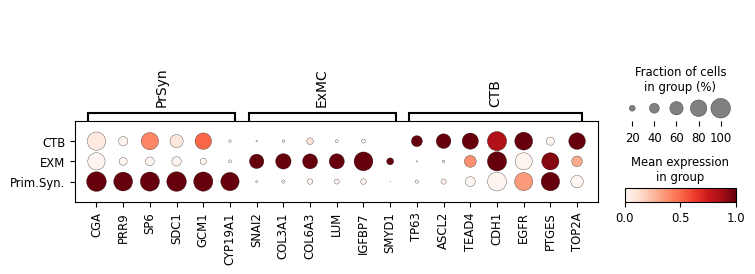

In [458]:
marker_genes = {
    #"Pluripotency": ["SOX2"],
    #"TE": ["GATA2", "GATA3", "TACSTD2", "ENPEP"],
    #"Peri-TB": ["VGLL1", "PHLDA2"],
    "PrSyn": ["CGA", "PRR9", "SP6", "SDC1", "GCM1", "CYP19A1"],
    "ExMC": ["SNAI2", "COL3A1", "COL6A3", "LUM", "IGFBP7", "SMYD1"],
    #"Cycling-Cell": ["MKI67", "CCNB1", "CENPF", "TOP2A", "CCNA2"],
    "CTB": ["TP63", "ASCL2", "TEAD4", "CDH1", "EGFR", "PTGES", "TOP2A"]
}
sc.pl.dotplot(ad6_coarse, marker_genes, groupby=cell_type_anno_col, standard_scale="var")


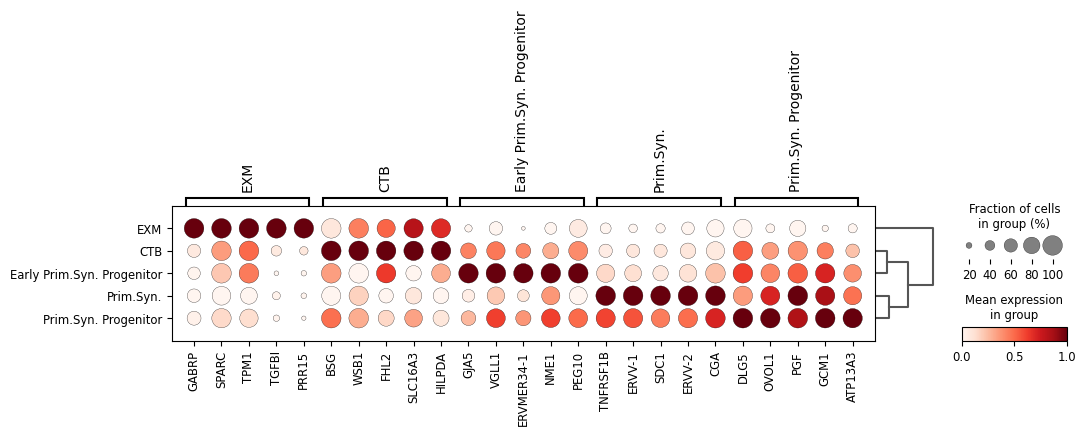

In [437]:
sc.pl.rank_genes_groups_dotplot(
    ad6_sub, groupby=cell_type_anno_col, standard_scale="var", n_genes=5
)

In [449]:
ad6_coarse = ad6_sub[[x in coarse_cell_types for x in ad6_sub.obs[cell_type_anno_col]]].copy()
sc.tl.rank_genes_groups(ad6_coarse, groupby=cell_type_anno_col, method="wilcoxon", rankby_abs = False)

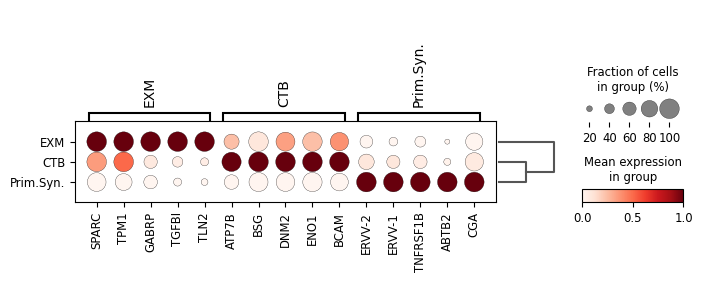

In [451]:
sc.tl.dendrogram(ad6_coarse, groupby = cell_type_anno_col)
sc.pl.rank_genes_groups_dotplot(
    ad6_coarse, groupby=cell_type_anno_col, standard_scale="var", n_genes=5, var_group_labels = coarse_cell_types
)

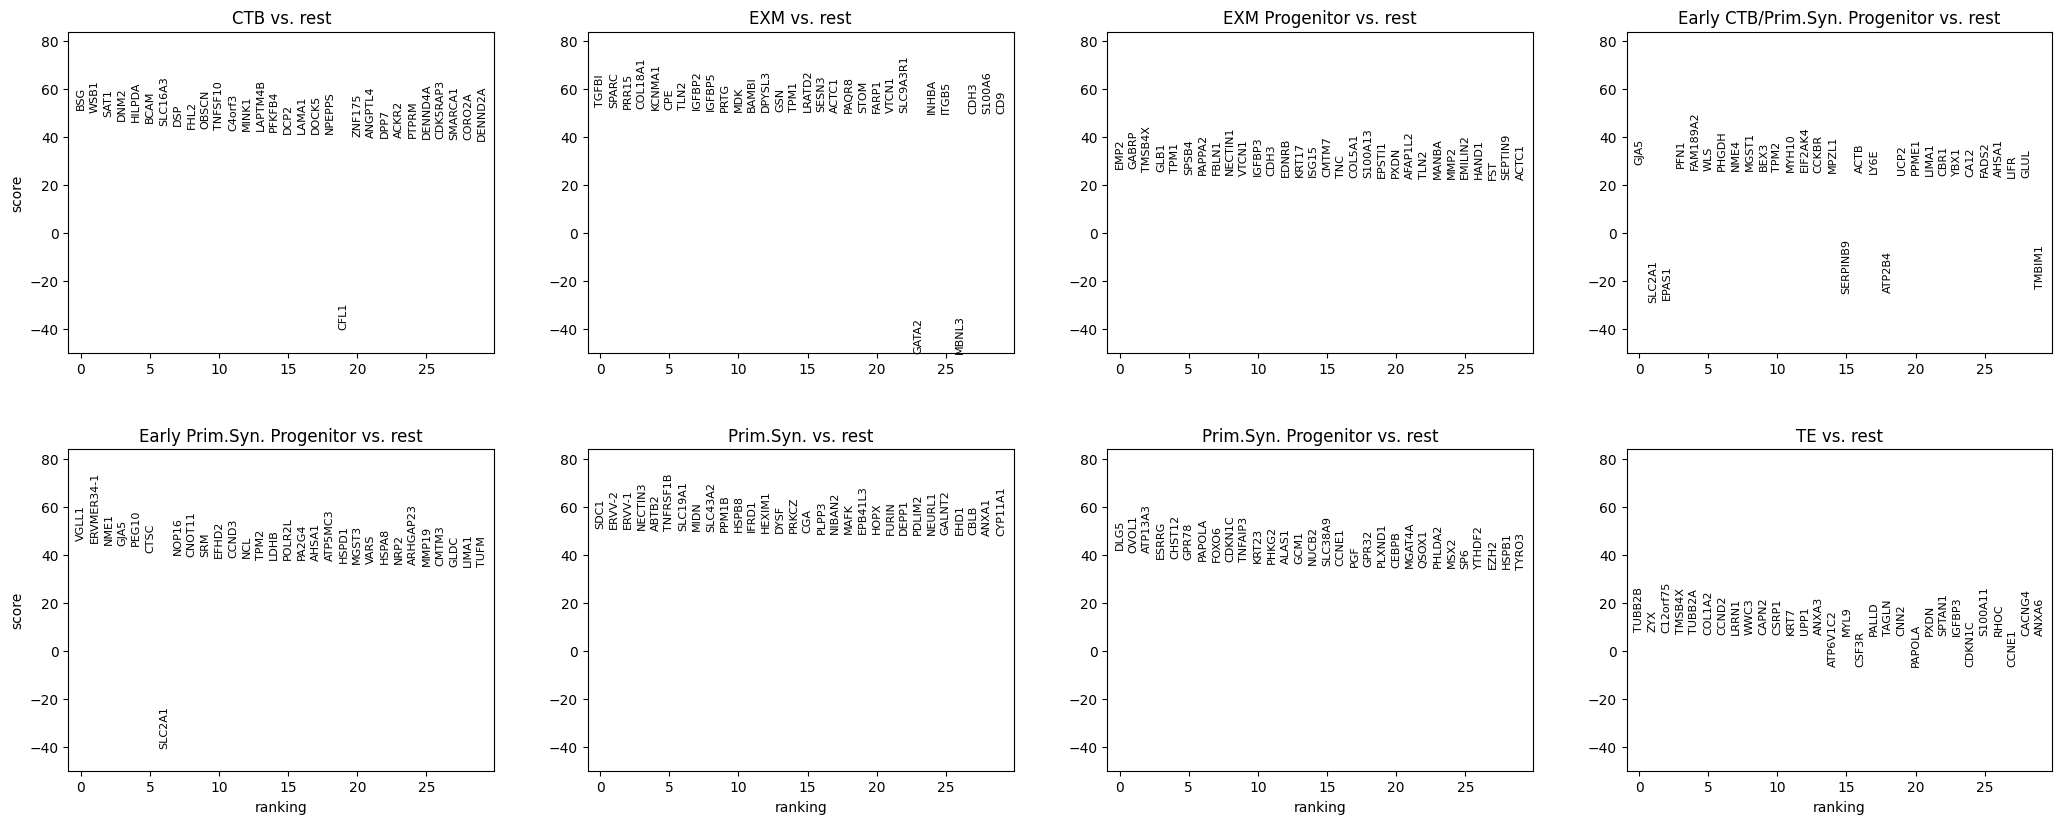

In [64]:
sc.pl.rank_genes_groups(ad6,n_genes=30)

In [40]:
ad6.uns['rank_genes_groups']['names'][0]

('BSG', 'TGFBI', 'EMP2', 'GJA5', 'VGLL1', 'SDC1', 'DLG5', 'TUBB2B')

In [85]:
# help(sc.pp.neighbors)

In [86]:
# help(sc.tl.rank_genes_groups)

(7896, 2236)

In [164]:
ad[ad.obs.Day == '6',:].obs.groupby(['Hyp/Norm',cell_type_anno_col]).size()

/tmp/ipykernel_2133146/2220618630.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ad[ad.obs.Day == '6',:].obs.groupby(['Hyp/Norm','Annotated Cell Types']).size()


Hyp/Norm  Annotated Cell Types          
Hypoxia   CTB                               1847
          EXM                                943
          EXM Progenitor                      16
          Early CTB/Prim.Syn. Progenitor     388
          Early Prim.Syn. Progenitor          10
          Prim.Syn.                          243
          Prim.Syn. Progenitor               139
          TE                                  12
Normoxia  CTB                                161
          EXM                                168
          EXM Progenitor                     306
          Early CTB/Prim.Syn. Progenitor     586
          Early Prim.Syn. Progenitor        1383
          Prim.Syn.                          832
          Prim.Syn. Progenitor               842
          TE                                  20
dtype: int64

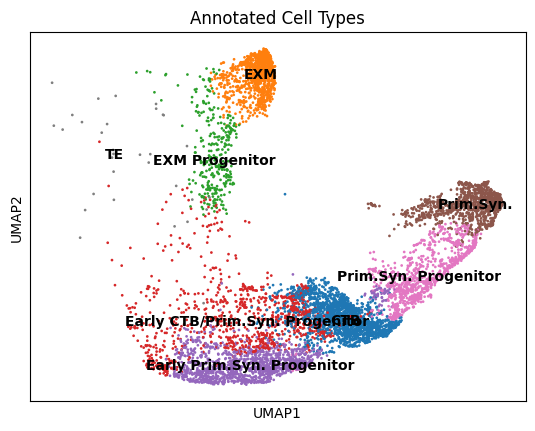

In [18]:
sc.pl.umap(ad[ad.obs.Day == '6',:], color=cell_type_anno_col, legend_loc="on data")

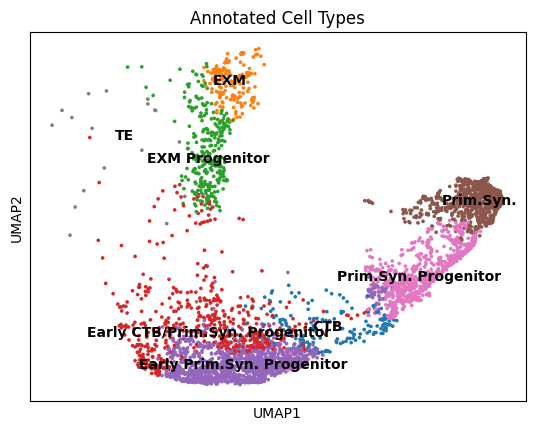

In [435]:
sc.pl.umap(ad[[day == '6' and norm == 'Normoxia' for day, norm in zip(ad.obs.Day, ad.obs['Hyp/Norm'])],:], color=cell_type_anno_col, legend_loc="on data")

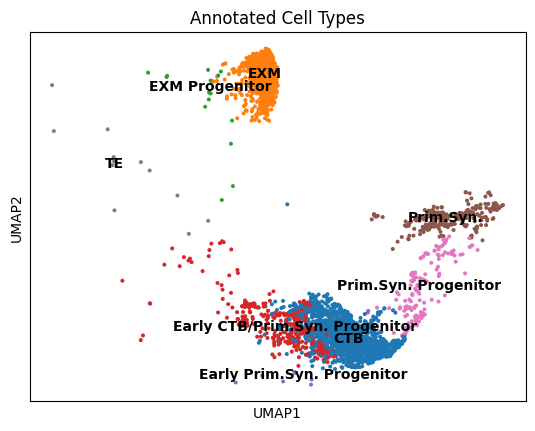

In [436]:
sc.pl.umap(ad[[day == '6' and norm == 'Hypoxia' for day, norm in zip(ad.obs.Day, ad.obs['Hyp/Norm'])],:], color=cell_type_anno_col, legend_loc="on data")

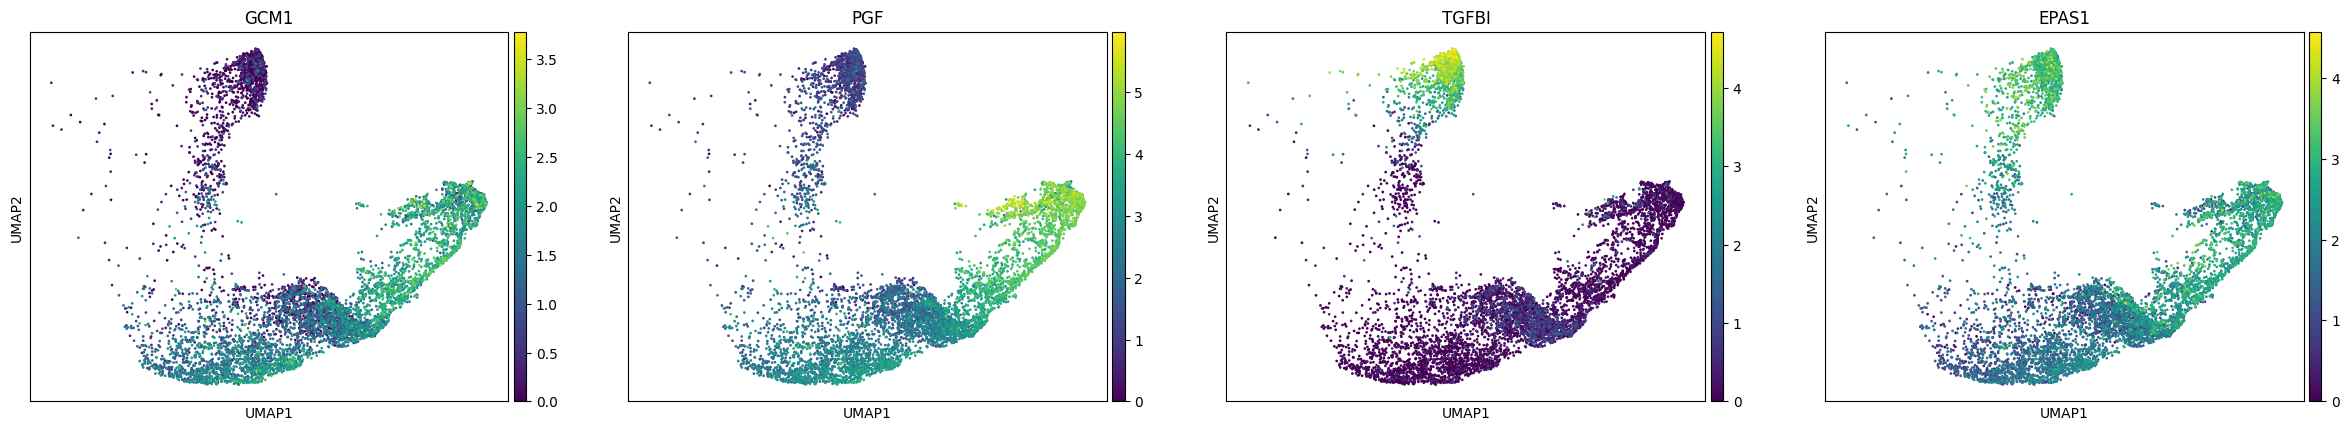

In [65]:
sc.pl.umap(ad6, color=['GCM1', 'PGF', 'TGFBI', 'EPAS1'])

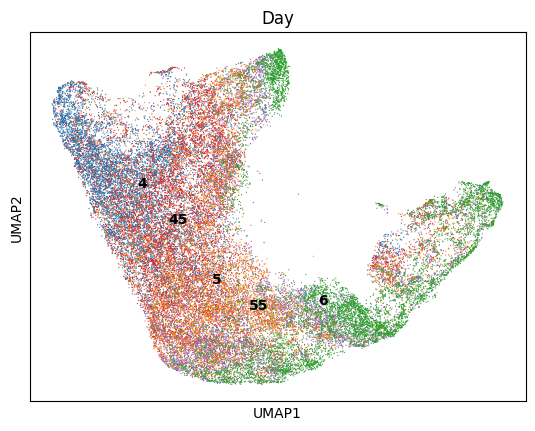

In [14]:
sc.pl.umap(ad, color="Day", legend_loc="on data")

In [452]:
#help(sc.pl.umap)

In [ ]:
## path=/home/bwhite/Tumor-Deconvolution-Challenge/analysis/validation-analysis/
## token=52bb80f372d0837760829bbfa321149f
## user=brian.white@jax.org
docker run -v /Users/whitebr/work/jax/projects/morphic/jax/csx-bulk-batches/:/src/data -v /Users/whitebr/work/jax/projects/morphic/jax/csx-bulk-batches/output/:/src/outdir cibersortx/fractions --username brian.white@jax.org --token 52bb80f372d0837760829bbfa321149f --mixture csx-bulk-batch_20230809_23-robson-005-run2.tsv --rmbatchBmode TRUE --perm 1 --verbose TRUE --QN FALSE --sourceGEPs CIBERSORTx_Job43_cell_type_sourceGEP.txt --sigmatrix CIBERSORTx_Job43_Early_Development_Differentiation_Hypoxia_Normoxia_Raw_300_ExM_PrSyn_CTB_inferred_phenoclasses.CIBERSORTx_Job43_Early_Development_Differentiation_Hypoxia_Normoxia_Raw_300_ExM_PrSyn_CTB_inferred_refsample.bm.K999.txt

cp CIBERSORTx_Job43_Early_Development_Differentiation_Hypoxia_Normoxia_Raw_300_ExM_PrSyn_CTB_inferred_phenoclasses.CIBERSORTx_Job43_Early_Development_Differentiation_Hypoxia_Normoxia_Raw_300_ExM_PrSyn_CTB_inferred_refsample.bm.K999.txt sigmatrix.txt

cd /Users/whitebr/work/jax/projects/morphic/jax/csx-bulk-batches

# Bah! Note that docker does not support absolute mode.
# We can run, but get all zeros.
# This is my experience and noted here: https://www.biostars.org/p/9567252/
for x in `ls *.tsv`
do 
  base=`basename $x .tsv`
  echo $base
  docker run -v /Users/whitebr/work/jax/projects/morphic/jax/csx-bulk-batches/:/src/data \
             -v /Users/whitebr/work/jax/projects/morphic/jax/csx-bulk-batches/output/:/src/outdir cibersortx/fractions \
             --username brian.white@jax.org --token 52bb80f372d0837760829bbfa321149f \
             --mixture $x \
             --sigmatrix sigmatrix.txt \
             --rmbatchSmode TRUE --perm 1 --verbose TRUE --QN FALSE \
             --absolute TRUE \
             --refsample Early_Development_Differentiation_Hypoxia_Normoxia_Raw_300_ExM_PrSyn_CTB.tsv
  mv output/CIBERSORTx_Adjusted.txt output/CIBERSORTx_Adjusted_${base}.txt
  mv output/CIBERSORTx_Mixtures_Adjusted.txt output/CIBERSORTx_Mixtures_Adjusted_${base}.txt
done


docker run -v /Users/whitebr/work/jax/projects/morphic/jax/csx-bulk-batches/:/src/data \
           -v /Users/whitebr/work/jax/projects/morphic/jax/csx-bulk-batches/output/:/src/outdir cibersortx/fractions \
           --username brian.white@jax.org --token 52bb80f372d0837760829bbfa321149f \
           --mixture csx-bulk-batch_20230809_23-robson-005-run2.tsv \
           --sigmatrix sigmatrix.txt \
           --rmbatchBmode TRUE --perm 1 --verbose TRUE --QN FALSE \
           --sourceGEPs /src/data/CIBERSORTx_Job43_cell_type_sourceGEP.txt 


"docker run",
                     " -v ", csx.input.dir, ":/src/data",
                     " -v ", csx.output.dir, ":/src/outdir",
                     " cibersortx/fractions",
                     " --username ", username, 
                     " --token ", token,
                     " --mixture ", input,
                     " --rmbatchBmode TRUE",
                     " --perm 1",
                     " --verbose TRUE",
                     " --QN FALSE")
--username      <string>  Email used for login to cibersortx.stanford.edu
--token         <string>  Token associated with current IP address (generated on website)

Primary Options:
--mixture       <file_name>  Mixture matrix [required for running CIBERSORTx, optional for creating a custom signature matrix only]
--sigmatrix     <file_name>  Signature matrix [required: use preexisting matrix or create one]
--perm          <int>   No. of permutations for p-value calculation [default: 0]
--label         <char>  Sample label [default: none]
--rmbatchBmode  <bool>  Run B-mode batch correction [default: FALSE]
--rmbatchSmode  <bool>  Run S-mode batch correction [default: FALSE]
--sourceGEPs    <file_name>  Signature matrix GEPs for batch correction [default: sigmatrix]
--QN            <bool>  Run quantile normalization [default: FALSE]
--absolute      <bool>  Run absolute mode [default: FALSE]
--abs_method    <char>  Pick absolute method ['sig.score' (default) or 'no.sumto1']
--verbose       <bool>  Print verbose output to terminal [default: FALSE]
